# CASALS L1B arbitrary-bin georeferencing audit

New original-H5 full audit, 2026-10-09. This notebook reads the new diagnostics, not archived notebook results. Refh closure, internal consistency, and external absolute accuracy are separate evidence classes. See `findings.md` for the scientific judgment.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'casals_l1b').is_dir())
# Visible configuration; change only to another newly completed audit root.
AUDIT = ROOT / 'outputs/research/bin_georeferencing_audit/full_20261009'
GRANULES = sorted(p for p in AUDIT.iterdir() if (p / 'run_metadata.json').exists())
assert len(GRANULES) == 2, 'NOT VERIFIED: both full original-H5 results required'
for p in GRANULES:
    m = json.loads((p / 'run_metadata.json').read_text())
    assert m['full_traversal'] and m['source_unchanged']
    print(p.name, m['n_audited'], 'pulses;', m['n_rx_bins'], 'bins; SHA256', m['sha256_before'])

casals_l1b_20241112T165718_001_02 3604480 pulses; 2728 bins; SHA256 637ba73ca9966b86d9243987916c0e60b8fec76c8690d49b7048468ed308cb70
casals_l1b_20241118T171757_001_02 3604480 pulses; 2728 bins; SHA256 dac3d5ed0116083f98944e8d6b0e86f6d812f0f5e4f196cc010add5e382c149a


## Candidate comparison
H1 centers spanning endpoints; H2 centers inside edges; H3 reversed H1. H4 is an empirically inferred timing candidate, not an official timing contract. H5 is Refh anchored and closes identically by construction. H6 is unavailable as a physical range model because stored bin_size semantics are undocumented.

In [2]:
display(pd.read_csv(AUDIT / 'comparison/model_comparison.csv'))

,granule,model,status,refh_independent,coordinate_reference,limitations,n_total,n_valid,valid_fraction,median,P95,max
0,casals_l1b_20241112T165718_001_02,H1,EVALUATED,True,EPSG:4978 m; EPSG:4979 ellipsoidal h,closure != absolute accuracy; H4 offset unit e...,3604480.0,3604480.0,1.0,0.016317,0.068740,0.074928
1,casals_l1b_20241112T165718_001_02,H2,EVALUATED,True,EPSG:4978 m; EPSG:4979 ellipsoidal h,closure != absolute accuracy; H4 offset unit e...,3604480.0,3604480.0,1.0,0.000527,0.000551,0.000555
2,casals_l1b_20241112T165718_001_02,H3,EVALUATED,True,EPSG:4978 m; EPSG:4979 ellipsoidal h,closure != absolute accuracy; H4 offset unit e...,3604480.0,3604480.0,1.0,91.578579,374.855521,408.728985
3,casals_l1b_20241112T165718_001_02,H4_empirical,EVALUATED,True,EPSG:4978 m; EPSG:4979 ellipsoidal h,closure != absolute accuracy; H4 offset unit e...,3604480.0,3604480.0,1.0,0.000527,0.000551,0.000555
4,casals_l1b_20241112T165718_001_02,H5,EVALUATED,False,EPSG:4978 m; EPSG:4979 ellipsoidal h,closure != absolute accuracy; H4 offset unit e...,3604480.0,3604480.0,1.0,0.000000,0.000000,0.000000
5,casals_l1b_20241112T165718_001_02,H6,UNAVAILABLE,False,EPSG:4978 m; EPSG:4979 ellipsoidal h,closure != absolute accuracy; H4 offset unit e...,NaN,NaN,NaN,NaN,NaN,NaN
6,casals_l1b_20241118T171757_001_02,H1,EVALUATED,True,EPSG:4978 m; EPSG:4979 ellipsoidal h,closure != absolute accuracy; H4 offset unit e...,3604480.0,3604480.0,1.0,0.015488,0.028359,0.074928
7,casals_l1b_20241118T171757_001_02,H2,EVALUATED,True,EPSG:4978 m; EPSG:4979 ellipsoidal h,closure != absolute accuracy; H4 offset unit e...,3604480.0,3604480.0,1.0,0.000529,0.000543,0.000555
8,casals_l1b_20241118T171757_001_02,H3,EVALUATED,True,EPSG:4978 m; EPSG:4979 ellipsoidal h,closure != absolute accuracy; H4 offset unit e...,3604480.0,3604480.0,1.0,87.381857,156.927244,408.729082
9,casals_l1b_20241118T171757_001_02,H4_empirical,EVALUATED,True,EPSG:4978 m; EPSG:4979 ellipsoidal h,closure != absolute accuracy; H4 offset unit e...,3604480.0,3604480.0,1.0,0.000529,0.000543,0.000555


In [3]:
for p in GRANULES:
    display(Markdown('### '+p.name))
    display(pd.read_csv(p / 'bin_agreement_with_counts.csv'))
    display(pd.read_csv(p / 'block_uncertainty.csv'))
    display(pd.read_csv(p / 'split_summary.csv'))

### casals_l1b_20241112T165718_001_02

,subset,model,n_total,n_valid,n_rejected,valid_fraction,median,NMAD,P90,P95,P99,max,min,mean,population_total,n_used,screening_rejected,within_half_bin,within_one_bin,signed_bias
0,all,H1,3604480,3604480,0,1.0,0.108844,0.067648,0.416645,0.458545,0.491998,0.499820,0.000146,0.186740,3604480,3604480,0,1.0,1.0,-0.093760
1,all,H2,3604480,3604480,0,1.0,0.003514,0.000196,0.003632,0.003675,0.003698,0.003704,0.000002,0.002909,3604480,3604480,0,1.0,1.0,0.003514
2,high_quality,H1,16,16,0,1.0,0.102956,0.004085,0.105712,0.105896,0.105897,0.105898,0.087151,0.099557,3604480,16,3604464,1.0,1.0,-0.102956
3,high_quality,H2,16,16,0,1.0,0.003533,0.000010,0.003557,0.003562,0.003573,0.003576,0.003525,0.003541,3604480,16,3604464,1.0,1.0,0.003533


,metric,n_blocks,estimand,median,CI_low,CI_high
0,H1_3d_m,28,median of 512-sweep block medians,0.016261,0.015406,0.019791
1,H2_3d_m,28,median of 512-sweep block medians,0.000527,0.000513,0.000530
2,bin_delta_H1,28,median of 512-sweep block medians,-0.094679,-0.099643,-0.086411
3,bin_delta_H2,28,median of 512-sweep block medians,0.003517,0.003426,0.003536
4,refh_line_distance_m,28,median of 512-sweep block medians,0.000004,0.000004,0.000005
5,RW_vs_beam_refh_deg,28,median of 512-sweep block medians,0.000137,0.000126,0.000146


,split,H1_3d_m_count,H1_3d_m_median,H1_3d_m_max,H2_3d_m_count,H2_3d_m_median,H2_3d_m_max,bin_delta_H1_count,bin_delta_H1_median,bin_delta_H1_max,...,RW_vs_beam_refh_deg_median,RW_vs_beam_refh_deg_max,H1_3d_m_P95,H2_3d_m_P95,bin_delta_H1_P95,bin_delta_H2_P95,refh_line_distance_m_P95,RW_vs_beam_refh_deg_P95,n_total,n_valid
0,exploration,2752512,0.016261,0.074928,2752512,0.000527,0.000555,2752512,-0.092658,0.49982,...,0.000132,0.000338,0.068806,0.000551,0.420983,0.003675,0.000011,0.000214,2752512,2752512
1,validation_contiguous_block,851968,0.016592,0.074928,851968,0.000526,0.000555,851968,-0.096702,0.49982,...,0.000137,0.000292,0.068372,0.000551,0.414473,0.003674,0.000011,0.000207,851968,851968


### casals_l1b_20241118T171757_001_02

,subset,model,n_total,n_valid,n_rejected,valid_fraction,median,NMAD,P90,P95,P99,max,min,mean,population_total,n_used,screening_rejected,within_half_bin,within_one_bin,signed_bias
0,all,H1,3604480,3604480,0,1.0,0.103318,0.019089,0.158673,0.189176,0.423264,0.499819,0.000046,0.117242,3604480,3604480,0,1.0,1.0,-0.102216
1,all,H2,3604480,3604480,0,1.0,0.003531,0.000069,0.003602,0.003625,0.003678,0.003705,0.000001,0.003421,3604480,3604480,0,1.0,1.0,0.003531
2,high_quality,H1,178079,178079,0,1.0,0.111865,0.016488,0.124303,0.137577,0.169334,0.222439,0.053496,0.111990,3604480,178079,3426401,1.0,1.0,-0.111865
3,high_quality,H2,178079,178079,0,1.0,0.003500,0.000058,0.003556,0.003558,0.003566,0.003632,0.002819,0.003489,3604480,178079,3426401,1.0,1.0,0.003500


,metric,n_blocks,estimand,median,CI_low,CI_high
0,H1_3d_m,28,median of 512-sweep block medians,0.015406,0.014552,0.017044
1,H2_3d_m,28,median of 512-sweep block medians,0.000529,0.000522,0.000532
2,bin_delta_H1,28,median of 512-sweep block medians,-0.101666,-0.113144,-0.097068
3,bin_delta_H2,28,median of 512-sweep block medians,0.003533,0.003483,0.003552
4,refh_line_distance_m,28,median of 512-sweep block medians,0.000004,0.000001,0.000005
5,RW_vs_beam_refh_deg,28,median of 512-sweep block medians,0.000107,0.000106,0.000113


,split,H1_3d_m_count,H1_3d_m_median,H1_3d_m_max,H2_3d_m_count,H2_3d_m_median,H2_3d_m_max,bin_delta_H1_count,bin_delta_H1_median,bin_delta_H1_max,...,RW_vs_beam_refh_deg_median,RW_vs_beam_refh_deg_max,H1_3d_m_P95,H2_3d_m_P95,bin_delta_H1_P95,bin_delta_H2_P95,refh_line_distance_m_P95,RW_vs_beam_refh_deg_P95,n_total,n_valid
0,exploration,2752512,0.015543,0.074928,2752512,0.000529,0.000555,2752512,-0.102584,0.499819,...,0.000109,0.001133,0.027590,0.000542,-0.055920,0.003619,0.000011,0.000689,2752512,2752512
1,validation_contiguous_block,851968,0.015378,0.074928,851968,0.000529,0.000555,851968,-0.101479,0.499819,...,0.000108,0.001111,0.030737,0.000545,-0.027286,0.003637,0.000011,0.000653,851968,851968


## Field contract, timing and beam evidence
H5 lacks per-field semantic attributes. Official tutorial definitions and empirical relationships are kept separate; unknown correction application stays unknown. Conditional c/c2 diagnostics do not prove that bounce offsets are raw round-trip time.

In [4]:
for p in GRANULES:
    for name in ['field_contract.csv','timing_spacing_comparison.csv','beam_geometry_summary.csv']:
        display(Markdown(p.name+' / '+name))
        display(pd.read_csv(p / name))

casals_l1b_20241112T165718_001_02 / field_contract.csv

,field,path,shape,units,definition_evidence,source,description,scale,offset,explicit_missing_value,correction_applied,empirical_note
0,bg_mean,/bg_mean,[3604480],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
1,bg_std,/bg_std,[3604480],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
2,bin_size,/bin_size,[3604480],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
3,dac,/dac,[3604480],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,UNKNOWN,see findings.md; no unit inferred from name alone
4,delta_time,/delta_time,[3604480],UNKNOWN,Documented,https://book.cryointhecloud.com/l1b-waveforms-...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
...,...,...,...,...,...,...,...,...,...,...,...,...
63,tide_pole,/tide_pole,[3604480],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,UNKNOWN,see findings.md; no unit inferred from name alone
64,track_num,/track_num,[3604480],UNKNOWN,Documented,https://book.cryointhecloud.com/l1b-waveforms-...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
65,tracks,/tracks,[256],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
66,tx_bins,/tx_bins,[80],UNKNOWN,Documented,https://book.cryointhecloud.com/l1b-waveforms-...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone


casals_l1b_20241112T165718_001_02 / timing_spacing_comparison.csv

,metric,subset,n_total,n_valid,n_rejected,valid_fraction,median,NMAD,P90,P95,P99,max,min,mean
0,time_bin_delta_H1,all,3604480,3604480,0,1.0,-9.732405e-02,1.076081e-01,3.359604e-01,4.184384e-01,4.840543e-01,4.998167e-01,-4.998167e-01,-3.805698e-02
1,time_bin_delta_H1,high_quality,16,16,0,1.0,-1.064883e-01,4.076063e-03,-9.622434e-02,-9.484971e-02,-9.155059e-02,-9.072581e-02,-1.094208e-01,-1.030975e-01
2,time_bin_delta_H2,all,3604480,3604480,0,1.0,1.989520e-12,5.477943e-12,8.526513e-12,1.045919e-11,1.330136e-11,1.864464e-11,-1.676881e-11,1.809434e-12
3,time_bin_delta_H2,high_quality,16,16,0,1.0,4.320100e-12,4.045251e-12,7.730705e-12,8.355983e-12,8.765255e-12,8.867573e-12,-1.818989e-12,3.751666e-12
4,t_time_minus_geom,all,3604480,3604480,0,1.0,-1.288232e-06,7.169374e-08,-4.144955e-07,-2.155217e-07,-4.361863e-08,1.176310e-09,-1.357797e-06,-1.066234e-06
5,t_time_minus_geom,high_quality,16,16,0,1.0,-1.295122e-06,3.493122e-09,-1.292834e-06,-1.292471e-06,-1.292095e-06,-1.292001e-06,-1.310911e-06,-1.298191e-06
6,bounce_span,all,3604480,3604480,0,1.0,1.364000e-06,5.023244e-21,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06
7,bounce_span,high_quality,16,16,0,1.0,1.364000e-06,2.511622e-21,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06
8,bounce_step_per_bin,all,3604480,3604480,0,1.0,5.000000e-10,1.839567e-24,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10
9,bounce_step_per_bin,high_quality,16,16,0,1.0,5.000000e-10,9.197835e-25,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10


casals_l1b_20241112T165718_001_02 / beam_geometry_summary.csv

...

,field,path,shape,units,definition_evidence,source,description,scale,offset,explicit_missing_value,correction_applied,empirical_note
0,bg_mean,/bg_mean,[3604480],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
1,bg_std,/bg_std,[3604480],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
2,bin_size,/bin_size,[3604480],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
3,dac,/dac,[3604480],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,UNKNOWN,see findings.md; no unit inferred from name alone
4,delta_time,/delta_time,[3604480],UNKNOWN,Documented,https://book.cryointhecloud.com/l1b-waveforms-...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
...,...,...,...,...,...,...,...,...,...,...,...,...
63,tide_pole,/tide_pole,[3604480],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,UNKNOWN,see findings.md; no unit inferred from name alone
64,track_num,/track_num,[3604480],UNKNOWN,Documented,https://book.cryointhecloud.com/l1b-waveforms-...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
65,tracks,/tracks,[256],UNKNOWN,Unknown,H5 attributes (no semantic attributes in audit...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone
66,tx_bins,/tx_bins,[80],UNKNOWN,Documented,https://book.cryointhecloud.com/l1b-waveforms-...,NaN,1,0,NONE,NaN,see findings.md; no unit inferred from name alone


casals_l1b_20241118T171757_001_02 / timing_spacing_comparison.csv

,metric,subset,n_total,n_valid,n_rejected,valid_fraction,median,NMAD,P90,P95,P99,max,min,mean
0,time_bin_delta_H1,all,3604480,3604480,0,1.0,-1.057551e-01,1.902163e-02,-7.716276e-02,-5.370235e-02,3.513563e-01,4.998167e-01,-4.998167e-01,-1.031982e-01
1,time_bin_delta_H1,high_quality,178079,178079,0,1.0,-1.152859e-01,1.630425e-02,-9.989003e-02,-9.879032e-02,-8.669355e-02,-5.700147e-02,-2.252566e-01,-1.154773e-01
2,time_bin_delta_H2,all,3604480,3604480,0,1.0,9.094947e-13,3.371042e-12,5.456968e-12,7.275958e-12,1.000444e-11,1.182343e-11,-1.003286e-11,9.780811e-13
3,time_bin_delta_H2,high_quality,178079,178079,0,1.0,6.821210e-13,3.371042e-12,5.456968e-12,7.048584e-12,1.045919e-11,1.159606e-11,-8.867573e-12,9.414585e-13
4,t_time_minus_geom,all,3604480,3604480,0,1.0,-1.294371e-06,2.545839e-08,-1.183298e-06,-1.126108e-06,-3.830853e-07,4.858561e-10,-1.358069e-06,-1.254110e-06
5,t_time_minus_geom,high_quality,178079,178079,0,1.0,-1.282945e-06,2.137504e-08,-1.252115e-06,-1.221252e-06,-1.159493e-06,-1.033335e-06,-1.331450e-06,-1.278967e-06
6,bounce_span,all,3604480,3604480,0,1.0,1.364000e-06,0.000000e+00,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06
7,bounce_span,high_quality,178079,178079,0,1.0,1.364000e-06,0.000000e+00,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06,1.364000e-06
8,bounce_step_per_bin,all,3604480,3604480,0,1.0,5.000000e-10,0.000000e+00,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10
9,bounce_step_per_bin,high_quality,178079,178079,0,1.0,5.000000e-10,0.000000e+00,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10,5.000000e-10


casals_l1b_20241118T171757_001_02 / beam_geometry_summary.csv

,metric,subset,n_total,n_valid,n_rejected,valid_fraction,median,NMAD,P90,P95,P99,max,min,mean
0,RW_vs_IR_deg,all,3604480,3604480,0,1.0,0.000034,0.000003,0.000202,0.000228,0.000234,0.000247,2.890613e-05,0.000066
1,RW_vs_IR_deg,high_quality,178079,178079,0,1.0,0.000034,0.000003,0.000109,0.000227,0.000232,0.000237,2.971498e-05,0.000055
2,RW_vs_beam_refh_deg,all,3604480,3604480,0,1.0,0.000109,0.000008,0.000621,0.000681,0.000730,0.001133,1.185757e-05,0.000204
3,RW_vs_beam_refh_deg,high_quality,178079,178079,0,1.0,0.000110,0.000006,0.000332,0.000661,0.000714,0.000790,9.634010e-05,0.000171
4,RW_vs_beam_instrument_deg,all,3604480,3604480,0,1.0,0.001972,0.000140,0.012752,0.014899,0.015325,0.015532,1.806144e-03,0.004056
5,RW_vs_beam_instrument_deg,high_quality,178079,178079,0,1.0,0.001983,0.000129,0.006570,0.014882,0.015202,0.015530,1.808806e-03,0.003334
6,IR_vs_beam_deg,all,3604480,3604480,0,1.0,0.001938,0.000137,0.012551,0.014672,0.015092,0.015297,1.776456e-03,0.003990
7,IR_vs_beam_deg,high_quality,178079,178079,0,1.0,0.001949,0.000127,0.006461,0.014656,0.014971,0.015295,1.777994e-03,0.003280
8,RW_vs_beam_degrees_candidate_deg,all,3604480,3604480,0,1.0,88.477704,0.603838,101.512195,103.469582,103.889468,104.075881,8.746008e+01,90.915608
9,RW_vs_beam_degrees_candidate_deg,high_quality,178079,178079,0,1.0,88.565851,0.442335,94.826059,103.434261,103.798419,104.074789,8.746033e+01,90.126016


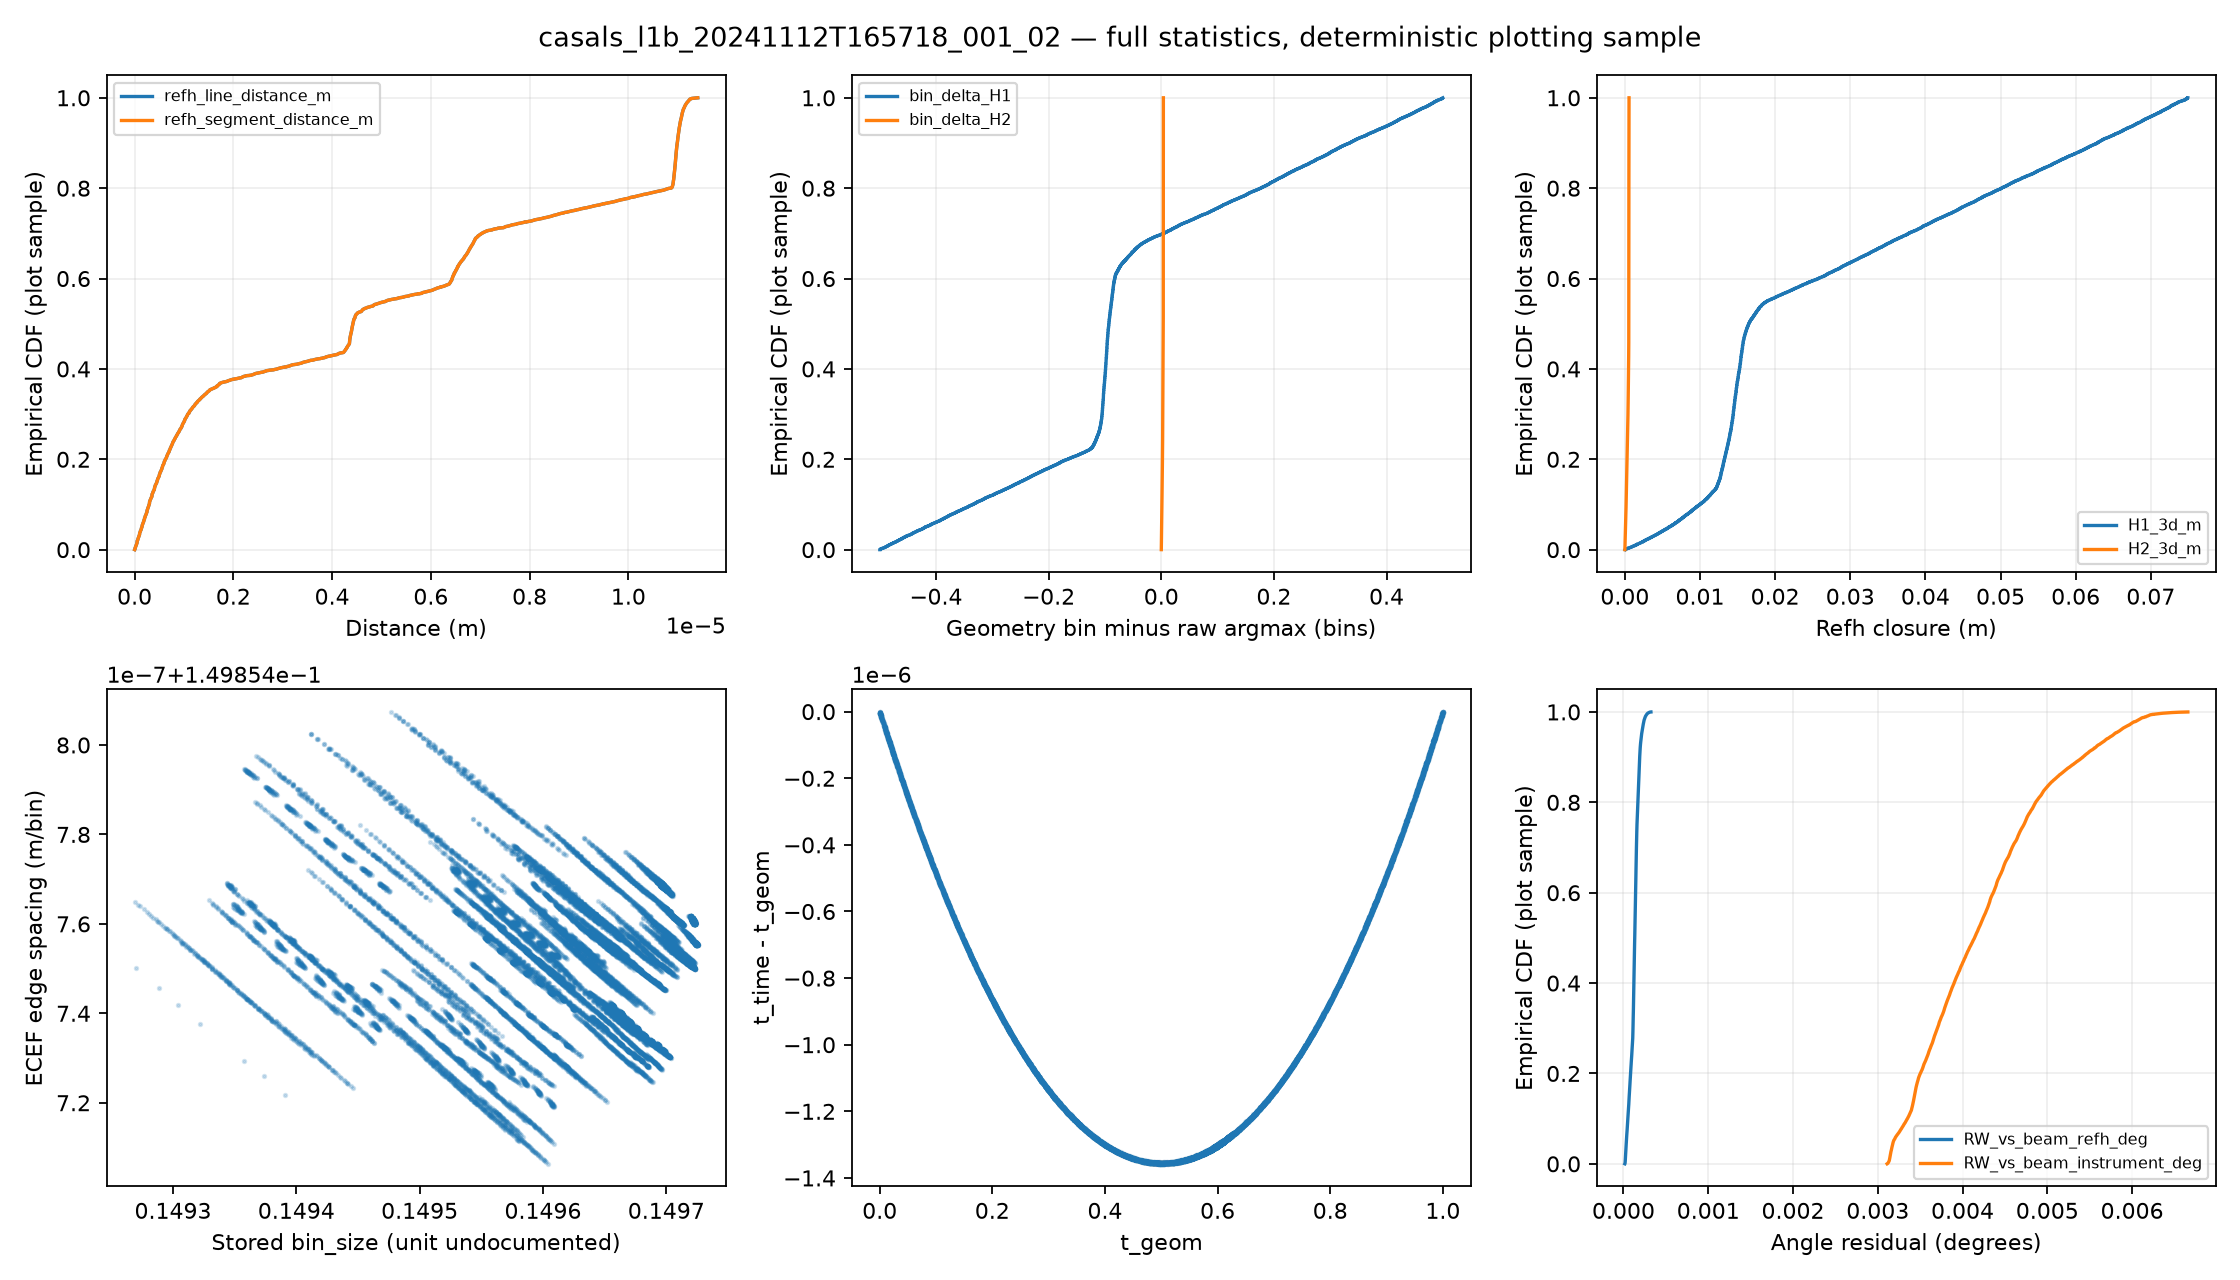

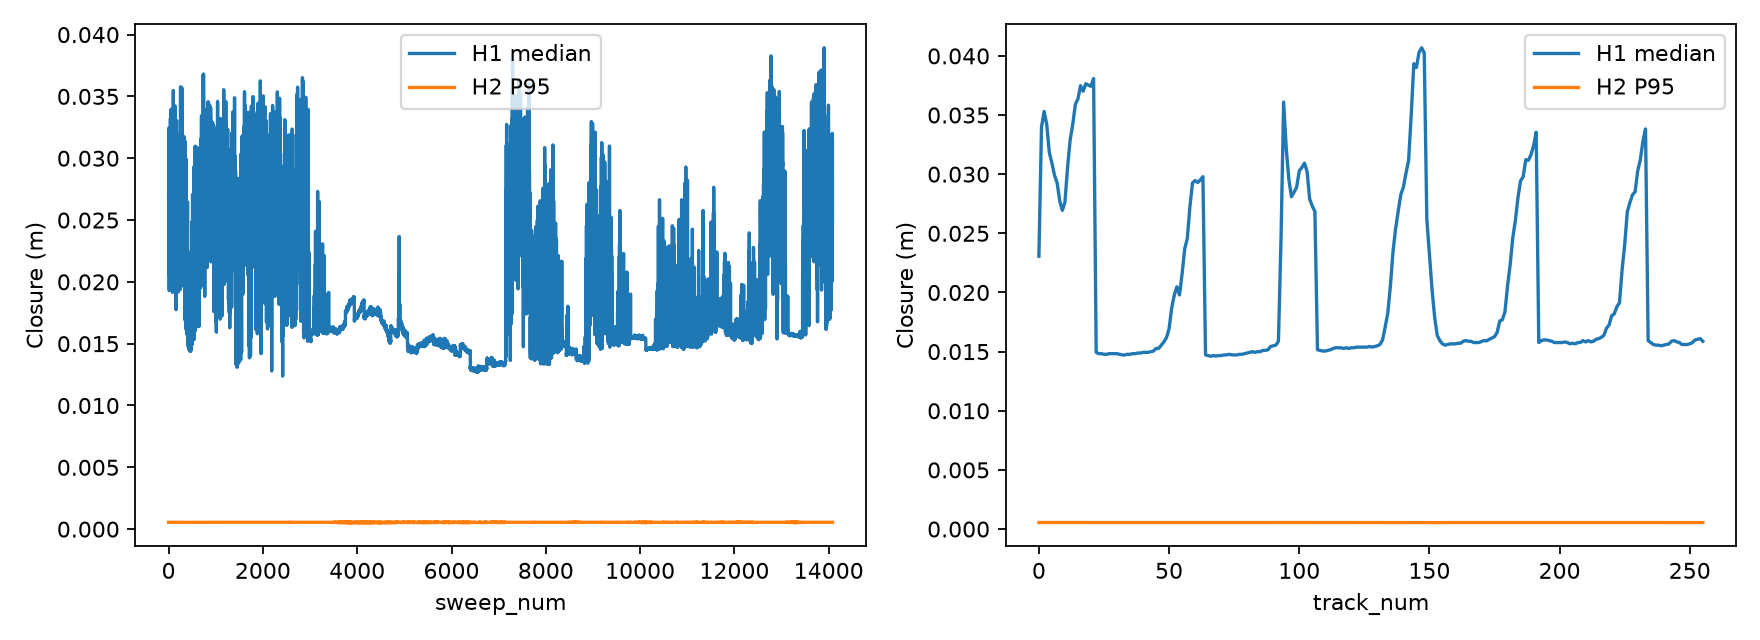

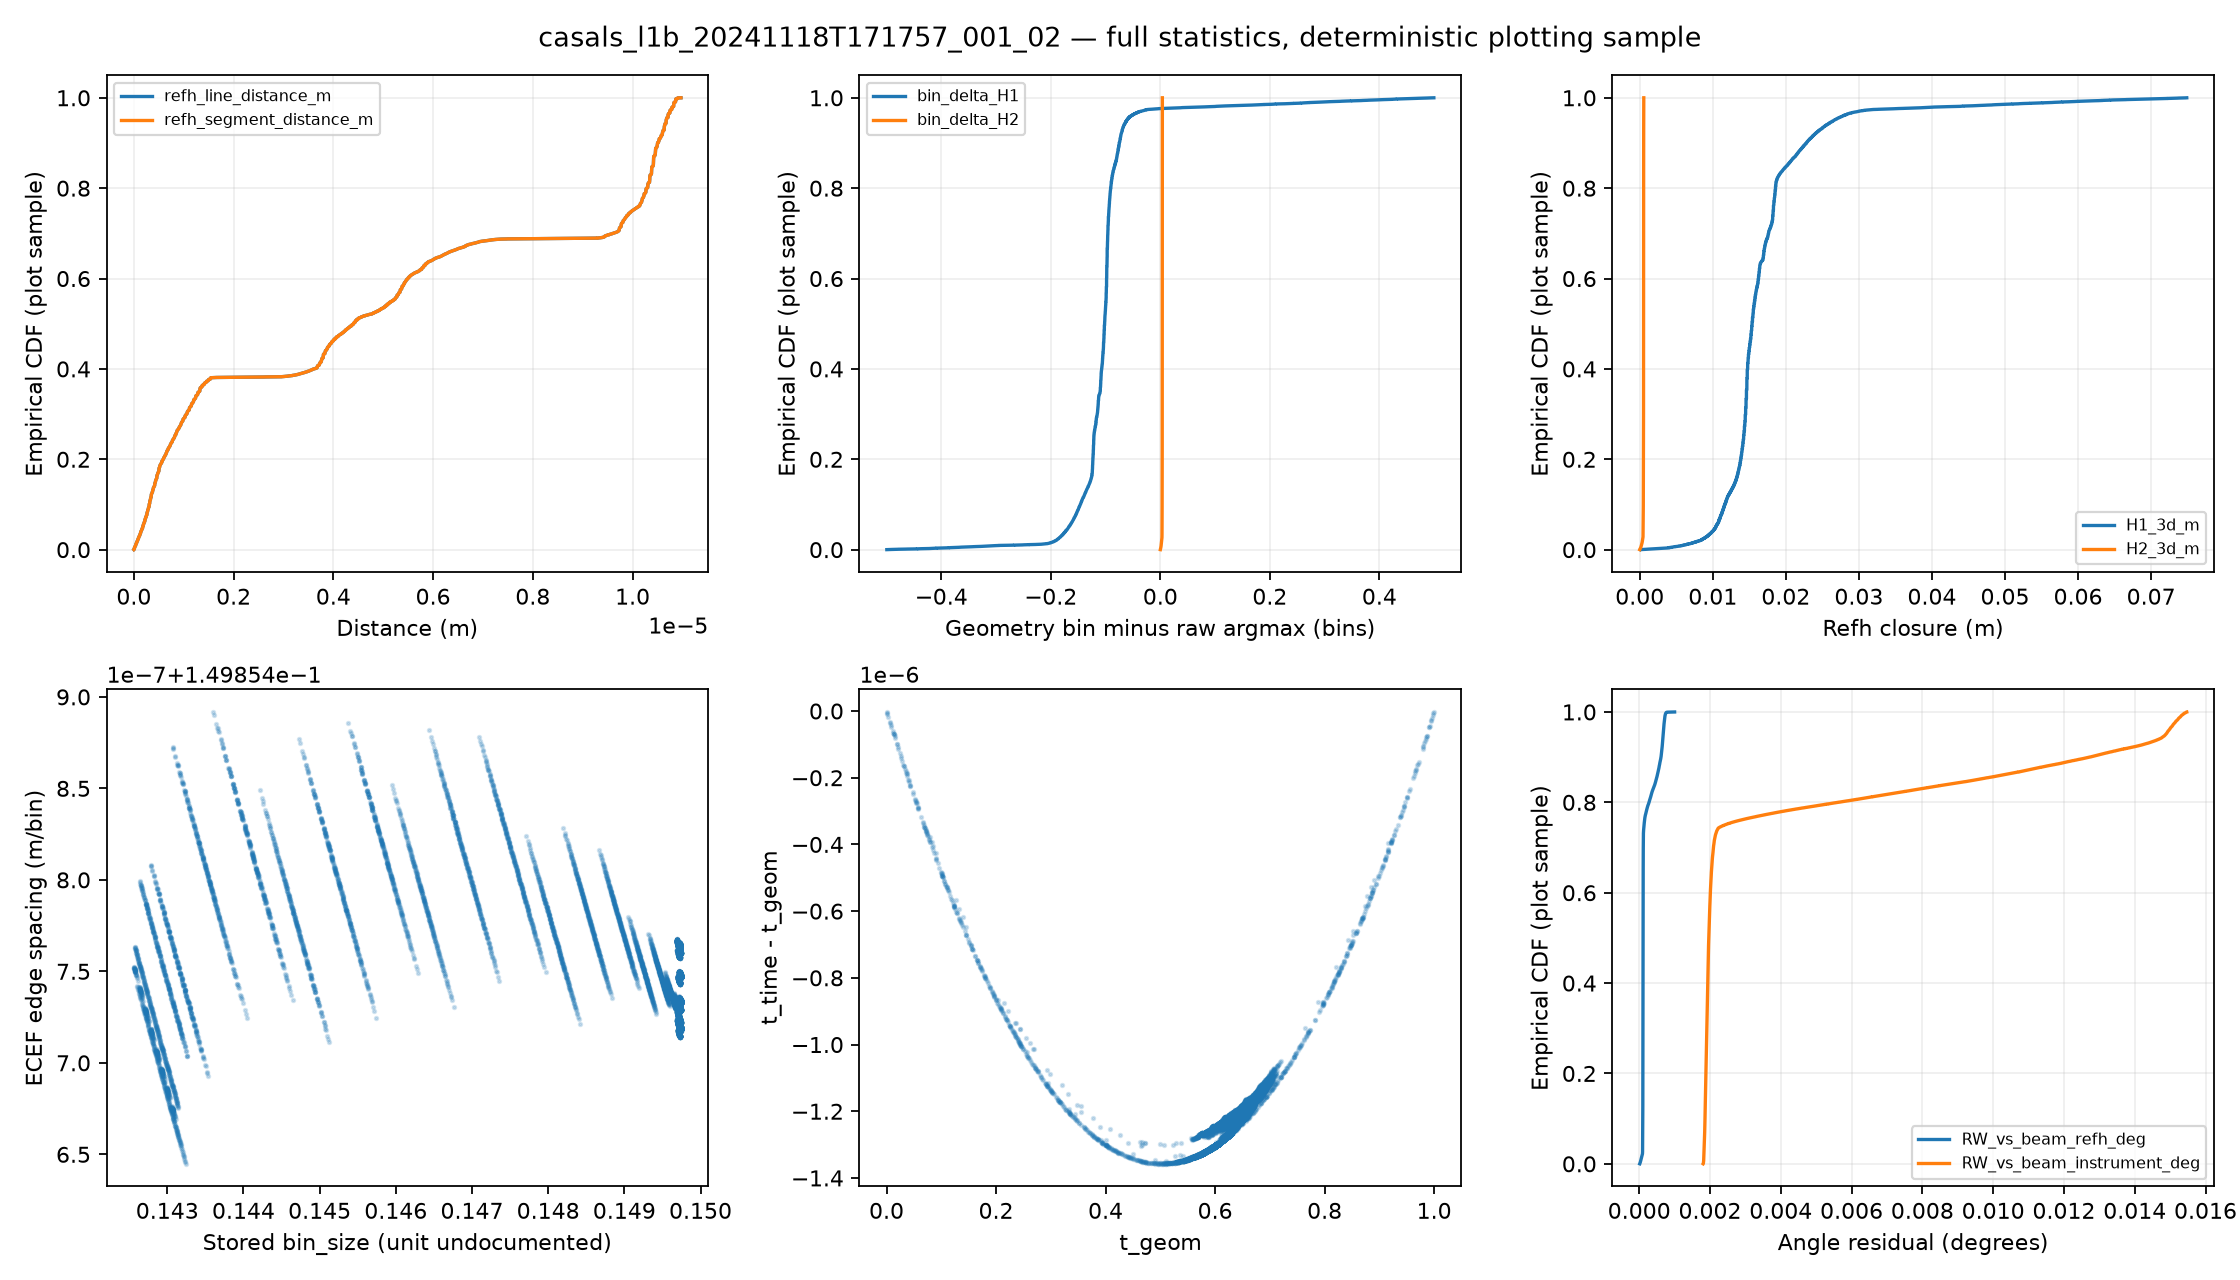

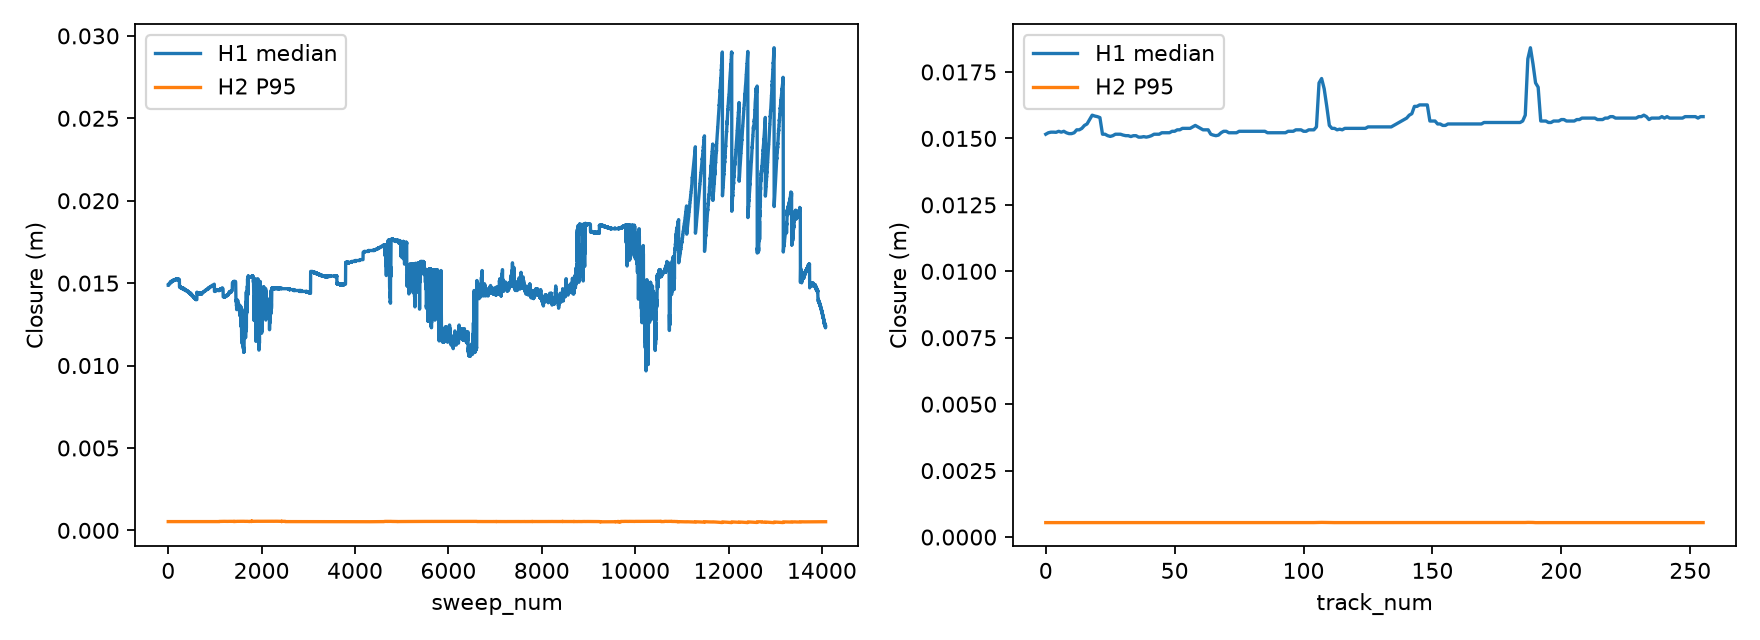

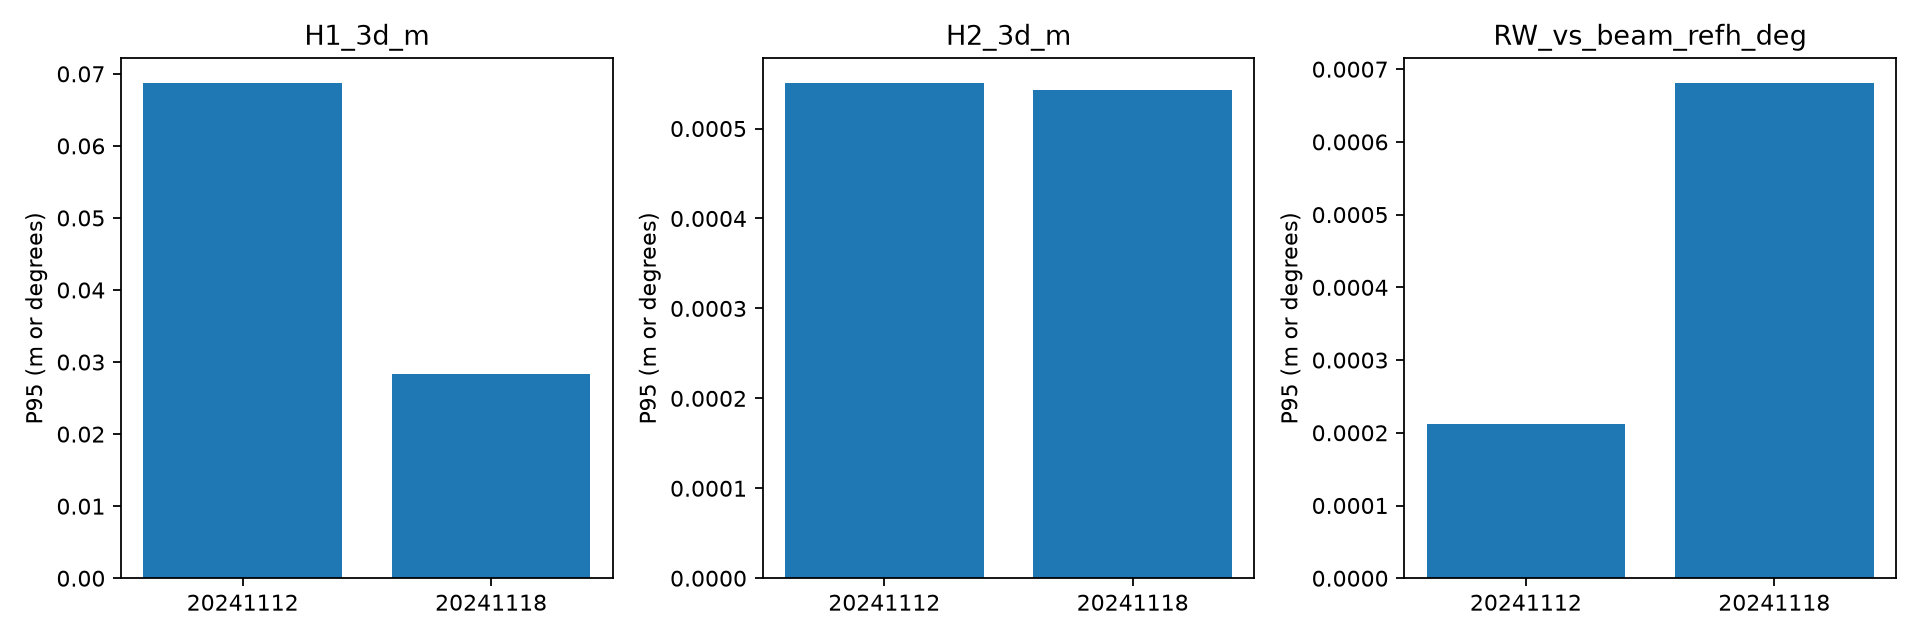

In [5]:
for p in GRANULES:
    display(Image(filename=str(p / 'figures/geometry_timing_beam.png')))
    display(Image(filename=str(p / 'figures/residual_by_sweep_track.png')))
display(Image(filename=str(AUDIT / 'comparison/figures/cross_granule.png')))

## Real non-reference bins and worst anomalies
Raw morphology examples are not classified landcover or certified physical scatterers. Fractional-bin coordinates represent samples of an affine L1B model. Each example retains pulse/sweep/track identity. Missing categories are explicit in sample_selection.json.

casals_l1b_20241112T165718_001_02 {'seed': 20261009, 'candidate_count': 170, 'categories': {'low_snr': 34, 'boundary': 13, 'near_tie': 4, 'wide': 2, 'multiple': 2}, 'rule': 'two seeded pulses per 512-sweep block/SNR/elevation stratum plus worst anomalies and historical case; raw scipy peaks prominence max(5,15% waveform span), distance 12; widths >=20 bins; classes are waveform morphology, not landcover', 'missing_categories': ['double', 'single', 'weak']}


,pulse_index,sweep_num,track_num,argmax_bin,amp_1693,amp_1694,max_amplitude,tie_count
0,1280218,5000,214,346,-42.0,-5.0,451.0,1


,pulse_index,sweep_num,track_num,valid,high_quality,refh_snr,beam_elevation,H1_3d_m,H2_3d_m,bin_delta_H1,...,RW_direction_x,RW_direction_y,RW_direction_z,sweep_block,split,beam_group,snr_group,segment_length_jump_m,direction_jump_deg,selection_reason
0,563521,2201,10,True,False,1.789178,1.509642,0.000025,0.000555,-0.000146,...,-0.167890,0.794557,-0.583516,4,exploration,"(1.45, 1.55]","(-inf, 3.0]",5.146376e-08,0.000474,top10_H2_3d_m
1,614944,2402,1,True,False,1.524582,1.512871,0.000572,0.000555,-0.003812,...,-0.170991,0.793009,-0.584721,4,exploration,"(1.45, 1.55]","(-inf, 3.0]",1.079324e-07,0.001211,top10_H2_3d_m
2,610466,2384,21,True,False,1.792011,1.511869,0.000407,0.000555,-0.002712,...,-0.169885,0.793463,-0.584428,4,exploration,"(1.45, 1.55]","(-inf, 3.0]",5.553562e-08,0.000672,top10_H2_3d_m
3,624517,2439,44,True,False,2.041435,1.511597,0.000407,0.000555,-0.002712,...,-0.169348,0.793531,-0.584491,4,exploration,"(1.45, 1.55]","(-inf, 3.0]",9.118037e-08,0.000911,top10_H2_3d_m
4,2289920,8945,0,True,False,1.689958,1.517637,0.000242,0.000555,-0.001613,...,-0.182278,0.791279,-0.583655,17,exploration,"(1.45, 1.55]","(-inf, 3.0]",9.937355e-08,0.001878,top10_H2_3d_m
5,611682,2389,19,True,False,1.957358,1.512001,0.000517,0.000555,-0.003446,...,-0.170035,0.793404,-0.584464,4,exploration,"(1.45, 1.55]","(-inf, 3.0]",9.709169e-08,0.000988,top10_H2_3d_m
6,603106,2355,23,True,False,1.645759,1.511438,0.000407,0.000555,-0.002712,...,-0.169455,0.793666,-0.584276,4,exploration,"(1.45, 1.55]","(-inf, 3.0]",1.229213e-07,0.001239,top10_H2_3d_m
7,562626,2197,22,True,False,1.804705,1.509093,0.000132,0.000555,-0.000880,...,-0.167218,0.794781,-0.583405,4,exploration,"(1.45, 1.55]","(-inf, 3.0]",1.211496e-07,0.001409,top10_H2_3d_m
8,575654,2248,53,True,False,1.751956,1.508610,0.000025,0.000555,-0.000147,...,-0.166569,0.794961,-0.583345,4,exploration,"(1.45, 1.55]","(-inf, 3.0]",1.238694e-07,0.001613,top10_H2_3d_m
9,599522,2341,23,True,False,1.847932,1.511228,0.000407,0.000555,-0.002713,...,-0.169278,0.793772,-0.584184,4,exploration,"(1.45, 1.55]","(-inf, 3.0]",1.061187e-07,0.001072,top10_H2_3d_m


,pulse_index,sweep_num,track_num,category,snr,selection_seed,bin,raw_argmax,is_detected_raw_peak,x,y,z,longitude,latitude,ellipsoidal_height,H5_minus_H2_m,continuity_step_error_m,finite,physical_return_verified
1,894,3,243,low_snr,1.997525,20261009,8.0,2700,True,1.271734e+06,-4.840617e+06,3.940795e+06,-75.279823,38.403719,217.570261,0.002377,4.705039e-11,True,False
2,894,3,243,low_snr,1.997525,20261009,30.0,2700,True,1.271734e+06,-4.840615e+06,3.940793e+06,-75.279821,38.403721,214.286575,0.002357,4.705039e-11,True,False
3,894,3,243,low_snr,1.997525,20261009,71.0,2700,True,1.271733e+06,-4.840610e+06,3.940789e+06,-75.279816,38.403724,208.166979,0.002321,4.705039e-11,True,False
4,894,3,243,low_snr,1.997525,20261009,86.0,2700,True,1.271733e+06,-4.840608e+06,3.940788e+06,-75.279814,38.403725,205.928102,0.002308,4.705039e-11,True,False
5,894,3,243,low_snr,1.997525,20261009,109.0,2700,True,1.271732e+06,-4.840605e+06,3.940786e+06,-75.279811,38.403727,202.495158,0.002288,4.705039e-11,True,False
6,894,3,243,low_snr,1.997525,20261009,132.0,2700,True,1.271732e+06,-4.840602e+06,3.940784e+06,-75.279809,38.403728,199.062214,0.002267,4.705039e-11,True,False
7,894,3,243,low_snr,1.997525,20261009,163.0,2700,True,1.271731e+06,-4.840599e+06,3.940781e+06,-75.279805,38.403731,194.435202,0.002240,4.705039e-11,True,False
8,894,3,243,low_snr,1.997525,20261009,190.0,2700,True,1.271730e+06,-4.840595e+06,3.940779e+06,-75.279802,38.403733,190.405224,0.002216,4.705039e-11,True,False
9,894,3,243,low_snr,1.997525,20261009,210.0,2700,True,1.271730e+06,-4.840593e+06,3.940777e+06,-75.279799,38.403734,187.420056,0.002198,4.705039e-11,True,False
10,894,3,243,low_snr,1.997525,20261009,222.0,2700,True,1.271730e+06,-4.840591e+06,3.940776e+06,-75.279798,38.403735,185.628954,0.002188,4.705039e-11,True,False


Largest continuity-step residual: 1.8082284558573747e-09


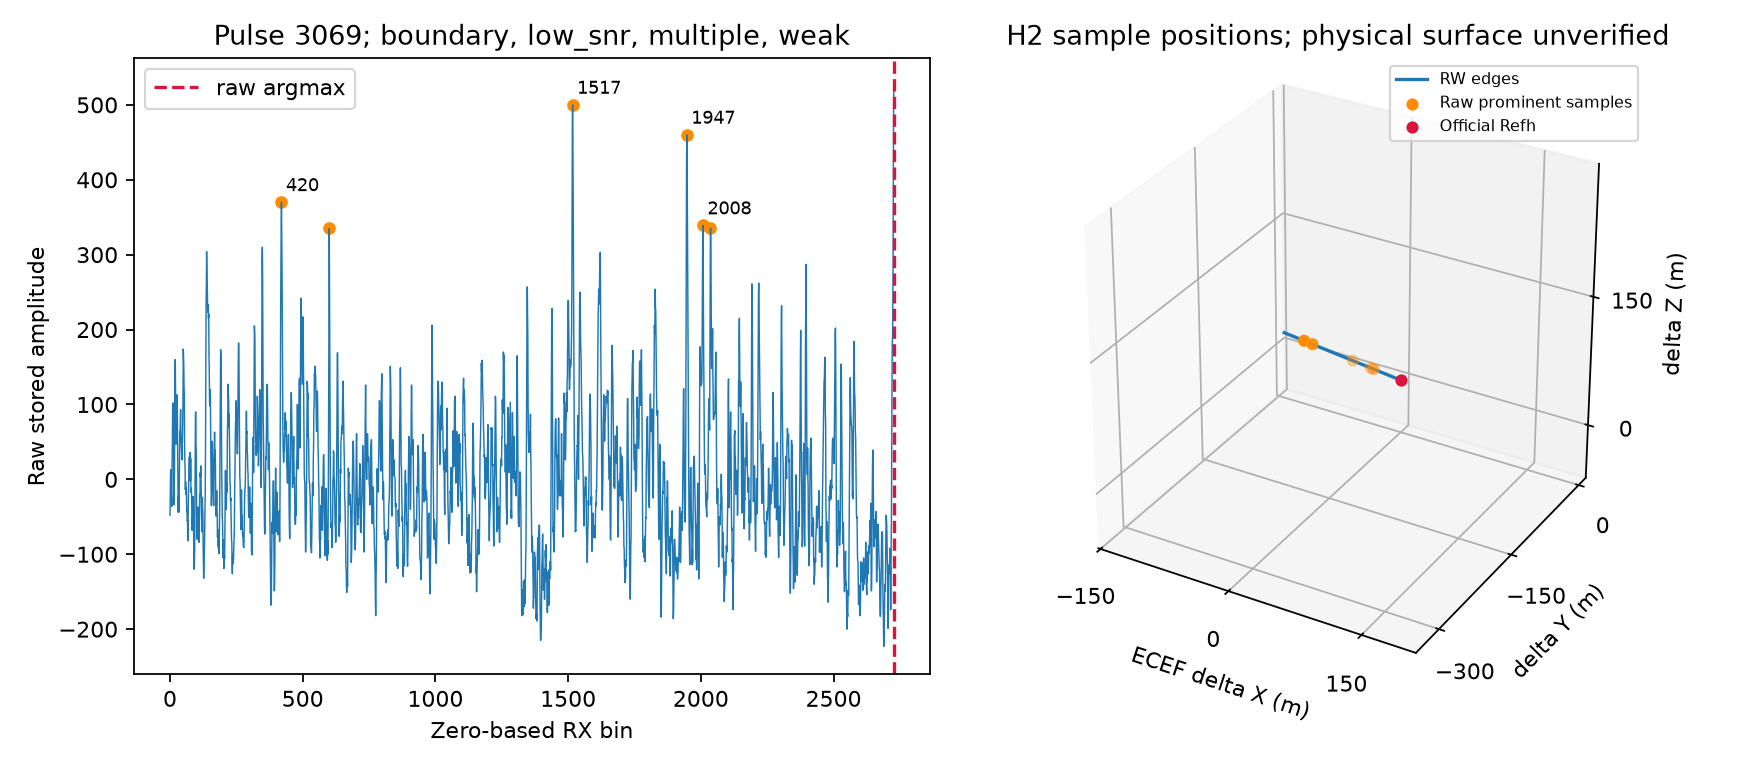

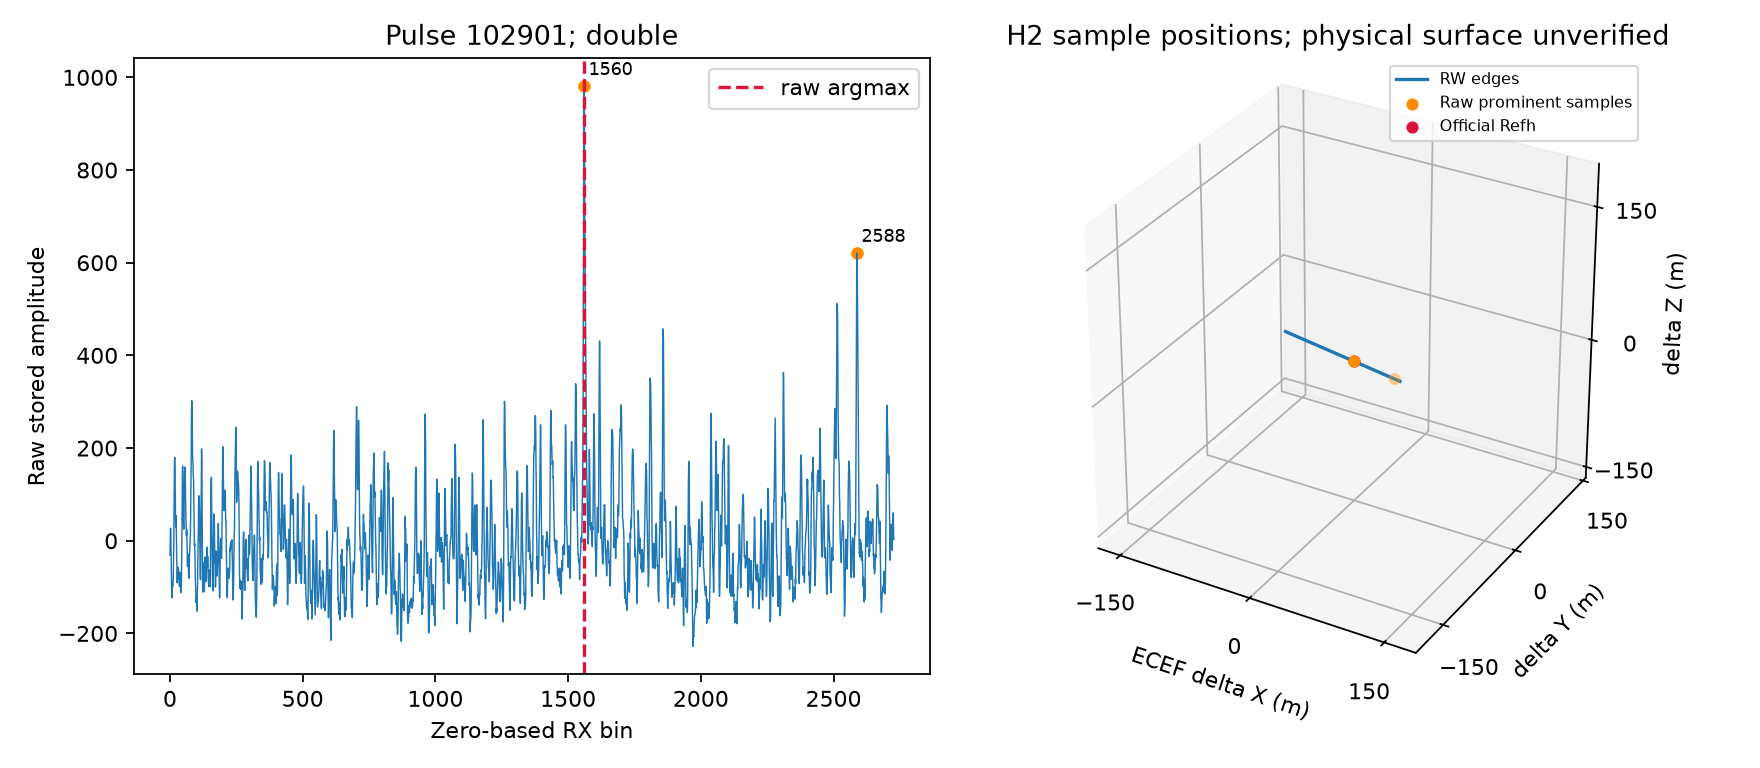

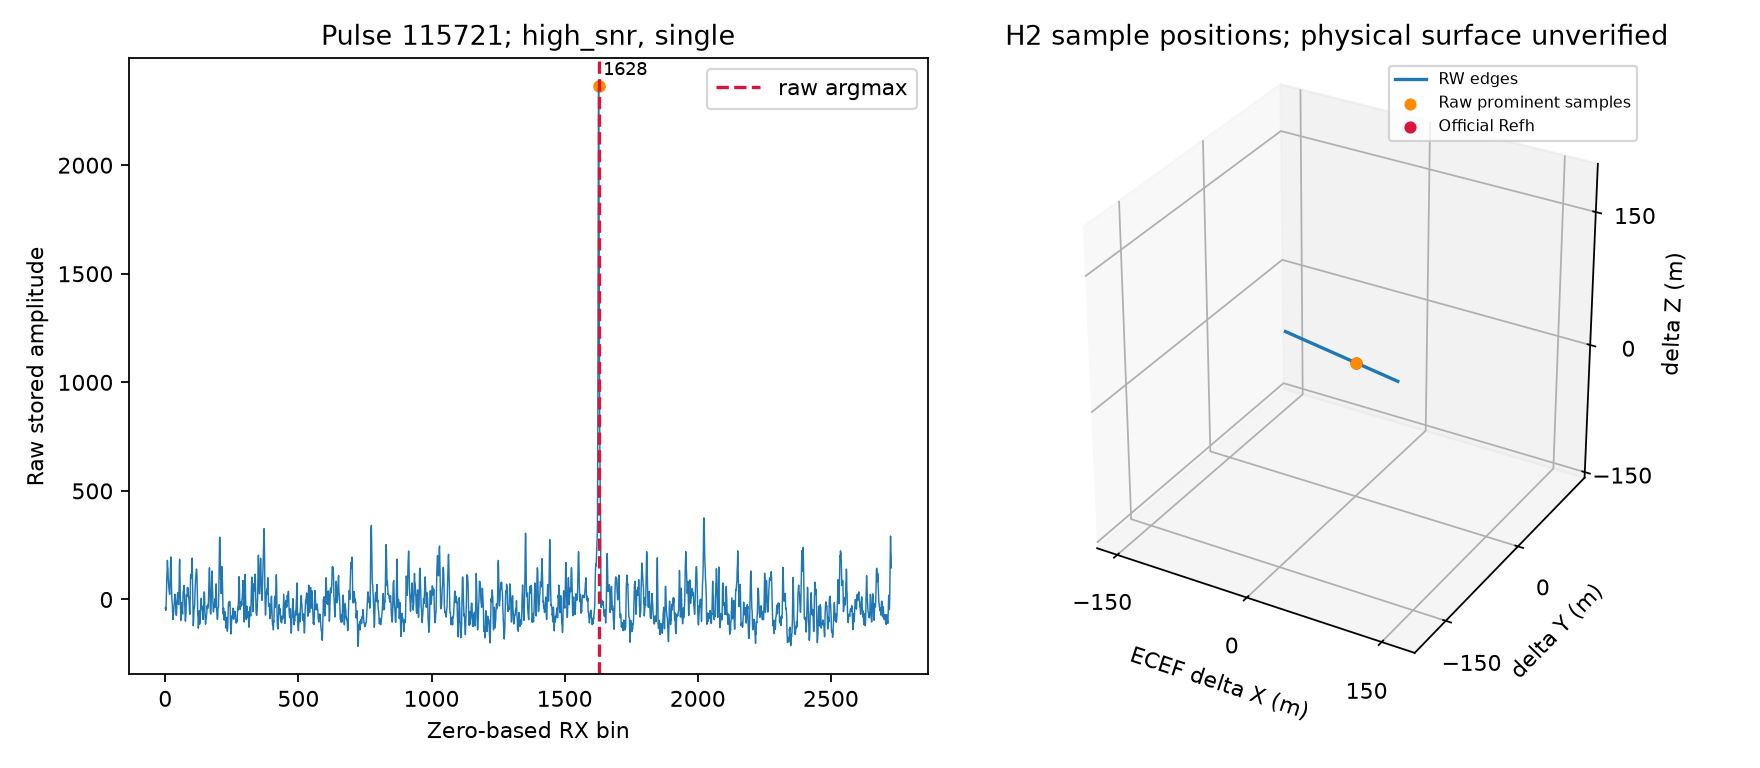

,pulse_index,sweep_num,track_num,labels,raw_peaks,raw_argmax,snr,n_raw_peaks,selection
0,894,3,243,"low_snr,multiple,weak","210,412,754,1540,1775,1993,2700",2700,1.997525,7,original seeded examples plus top5 stored SNR;...
1,3069,11,239,"boundary,low_snr,multiple,weak","420,600,1517,1947,2008,2036",2727,2.153650,6,original seeded examples plus top5 stored SNR;...
2,4574,17,246,"low_snr,multiple,near_tie,weak","5,77,500,541,628,1503,1666,1730,2678",2678,1.988279,9,original seeded examples plus top5 stored SNR;...
3,5436,21,225,"boundary,low_snr,multiple,weak,wide","940,1297,1359,1661,1884,2162,2495,2612",2725,2.011949,8,original seeded examples plus top5 stored SNR;...
4,47240,184,68,single,1605,1605,3.524740,1,original seeded examples plus top5 stored SNR;...
5,102901,401,175,double,"1560,2588",1560,3.458250,2,original seeded examples plus top5 stored SNR;...
6,115721,452,72,"high_snr,single",1628,1628,10.035976,1,original seeded examples plus top5 stored SNR;...


,metric,unit,n_total,n_valid,n_rejected,valid_fraction,median,NMAD,P90,P95,P99,max,min,mean
0,H2_along_minus_neutat_linear_residual,numerically compared stored correction to mete...,3604480,3604480,0,1.0,1.019743e-08,1.404634e-07,2.443650e-07,3.359712e-07,6.754187e-07,9.846989e-07,-9.989015e-07,-1.188031e-08
1,abs_H2_along_minus_neutat_linear_residual,NaN,3604480,3604480,0,1.0,9.610888e-08,1.073000e-07,4.499537e-07,5.626320e-07,7.457331e-07,9.989015e-07,1.303547e-14,1.675300e-07


,metric,subset,n_total,n_valid,n_rejected,valid_fraction,median,NMAD,P90,P95,P99,max,min,mean
0,H2_along_m,all,3604480,3604480,0,1.0,-0.000527,0.000029,-0.000169,-0.000088,-0.000018,4.812632e-07,-5.550728e-04,-0.000436
1,H2_along_m,high_quality,16,16,0,1.0,-0.000529,0.000001,-0.000529,-0.000528,-0.000528,-5.281750e-04,-5.359047e-04,-0.000531
2,H2_perp_m,all,3604480,3604480,0,1.0,0.000004,0.000005,0.000011,0.000011,0.000011,1.145337e-05,1.026573e-10,0.000005
3,H2_perp_m,high_quality,16,16,0,1.0,0.000004,0.000006,0.000011,0.000011,0.000011,1.104831e-05,1.520766e-07,0.000005
4,t_times_one_minus_t,all,3604480,3604480,0,1.0,0.237459,0.013202,0.245426,0.248418,0.249926,2.500000e-01,1.832509e-04,0.196512
5,t_times_one_minus_t,high_quality,16,16,0,1.0,0.238660,0.000879,0.240741,0.240998,0.241615,2.417688e-01,2.380271e-01,0.239334
6,neutat_ref_minus_linear,all,3604480,3604480,0,1.0,-0.000527,0.000029,-0.000169,-0.000088,-0.000018,-3.313651e-07,-5.549274e-04,-0.000436
7,neutat_ref_minus_linear,high_quality,16,16,0,1.0,-0.000529,0.000001,-0.000529,-0.000528,-0.000528,-5.281020e-04,-5.358395e-04,-0.000531
8,H5_Nminus1_vs_H2_first_m,all,3604480,3604480,0,1.0,0.088985,0.016161,0.123879,0.136941,0.147352,1.498738e-01,4.003379e-07,0.080199
9,H5_Nminus1_vs_H2_first_m,high_quality,16,16,0,1.0,0.090364,0.000611,0.090776,0.090804,0.090805,9.080490e-02,8.799552e-02,0.089854


casals_l1b_20241118T171757_001_02 {'seed': 20261009, 'candidate_count': 245, 'categories': {'low_snr': 14, 'multiple': 11, 'near_tie': 3, 'wide': 14, 'double': 2, 'boundary': 16, 'single': 2}, 'rule': 'two seeded pulses per 512-sweep block/SNR/elevation stratum plus worst anomalies and historical case; raw scipy peaks prominence max(5,15% waveform span), distance 12; widths >=20 bins; classes are waveform morphology, not landcover', 'missing_categories': ['weak']}


,pulse_index,sweep_num,track_num,argmax_bin,amp_1693,amp_1694,max_amplitude,tie_count
0,1280218,5000,214,1694,1850.0,1860.0,1860.0,1


,pulse_index,sweep_num,track_num,valid,high_quality,refh_snr,beam_elevation,H1_3d_m,H2_3d_m,bin_delta_H1,...,RW_direction_x,RW_direction_y,RW_direction_z,sweep_block,split,beam_group,snr_group,segment_length_jump_m,direction_jump_deg,selection_reason
0,158829,620,107,True,False,1.482520,1.530285,0.000418,0.000555,0.002787,...,-0.225553,0.777457,-0.587100,1,exploration,"(1.45, 1.55]","(-inf, 3.0]",2.355023e-09,0.001170,top10_H2_3d_m
1,177005,691,107,True,False,1.678017,1.530404,0.000253,0.000555,0.001687,...,-0.225379,0.776927,-0.587868,1,exploration,"(1.45, 1.55]","(-inf, 3.0]",2.356745e-08,0.000406,top10_H2_3d_m
2,182167,711,188,True,False,1.829361,1.528940,0.000473,0.000555,0.003153,...,-0.226905,0.778781,-0.584821,1,exploration,"(1.45, 1.55]","(-inf, 3.0]",1.908018e-07,0.000458,top10_H2_3d_m
3,11085,43,106,True,False,2.267084,1.528602,0.000583,0.000555,0.003886,...,-0.227103,0.776233,-0.588121,0,exploration,"(1.45, 1.55]","(-inf, 3.0]",3.899561e-08,0.001719,top10_H2_3d_m
4,162167,633,187,True,False,1.439543,1.528862,0.000747,0.000555,0.004986,...,-0.226963,0.779266,-0.584151,1,exploration,"(1.45, 1.55]","(-inf, 3.0]",1.687475e-07,0.000751,top10_H2_3d_m
5,220525,861,107,True,False,1.908262,1.529013,0.000857,0.000555,0.005719,...,-0.226746,0.776791,-0.587523,1,exploration,"(1.45, 1.55]","(-inf, 3.0]",1.932381e-07,0.000629,top10_H2_3d_m
6,193879,757,186,True,False,1.380127,1.528606,0.000198,0.000555,0.001320,...,-0.227232,0.778589,-0.584948,1,exploration,"(1.45, 1.55]","(-inf, 3.0]",2.727795e-07,0.001159,top10_H2_3d_m
7,242829,948,108,True,False,1.415835,1.528256,0.000802,0.000555,0.005353,...,-0.227535,0.777257,-0.586600,1,exploration,"(1.45, 1.55]","(-inf, 3.0]",1.737207e-07,0.001433,top10_H2_3d_m
8,1551785,6061,77,True,False,2.035102,1.531253,0.000418,0.000555,0.002787,...,-0.223136,0.772749,-0.594196,11,validation_contiguous_block,"(1.45, 1.55]","(-inf, 3.0]",1.817584e-07,0.000244,top10_H2_3d_m
9,872301,3407,107,True,False,1.716667,1.531031,0.000034,0.000555,0.000221,...,-0.224280,0.774943,-0.590899,6,exploration,"(1.45, 1.55]","(-inf, 3.0]",1.464878e-08,0.002240,top10_H2_3d_m


,pulse_index,sweep_num,track_num,category,snr,selection_seed,bin,raw_argmax,is_detected_raw_peak,x,y,z,longitude,latitude,ellipsoidal_height,H5_minus_H2_m,continuity_step_error_m,finite,physical_return_verified
1,11085,43,106,low_snr,2.267084,20261009,37.0,1363,True,1.187571e+06,-5.014895e+06,3.745562e+06,-76.677282,36.192373,207.154766,0.000640,8.247917e-10,True,False
2,11085,43,106,low_snr,2.267084,20261009,72.0,1363,True,1.187569e+06,-5.014891e+06,3.745559e+06,-76.677284,36.192373,201.914519,0.000635,8.247917e-10,True,False
3,11085,43,106,low_snr,2.267084,20261009,90.0,1363,True,1.187569e+06,-5.014888e+06,3.745557e+06,-76.677286,36.192373,199.219535,0.000633,8.247917e-10,True,False
4,11085,43,106,low_snr,2.267084,20261009,111.0,1363,True,1.187568e+06,-5.014886e+06,3.745556e+06,-76.677287,36.192373,196.075387,0.000631,8.247917e-10,True,False
5,11085,43,106,low_snr,2.267084,20261009,139.0,1363,True,1.187567e+06,-5.014883e+06,3.745553e+06,-76.677289,36.192373,191.883189,0.000628,8.247917e-10,True,False
6,11085,43,106,low_snr,2.267084,20261009,164.0,1363,True,1.187566e+06,-5.014880e+06,3.745551e+06,-76.677291,36.192374,188.140156,0.000625,8.247917e-10,True,False
7,11085,43,106,low_snr,2.267084,20261009,228.0,1363,True,1.187564e+06,-5.014872e+06,3.745545e+06,-76.677295,36.192374,178.557990,0.000618,8.247917e-10,True,False
8,11085,43,106,low_snr,2.267084,20261009,252.0,1363,True,1.187563e+06,-5.014870e+06,3.745543e+06,-76.677297,36.192374,174.964677,0.000616,8.247917e-10,True,False
9,11085,43,106,low_snr,2.267084,20261009,269.0,1363,True,1.187563e+06,-5.014868e+06,3.745542e+06,-76.677298,36.192374,172.419415,0.000614,8.247917e-10,True,False
10,11085,43,106,low_snr,2.267084,20261009,291.0,1363,True,1.187562e+06,-5.014865e+06,3.745540e+06,-76.677300,36.192374,169.125545,0.000612,8.247917e-10,True,False


Largest continuity-step residual: 1.3590088221437924e-09


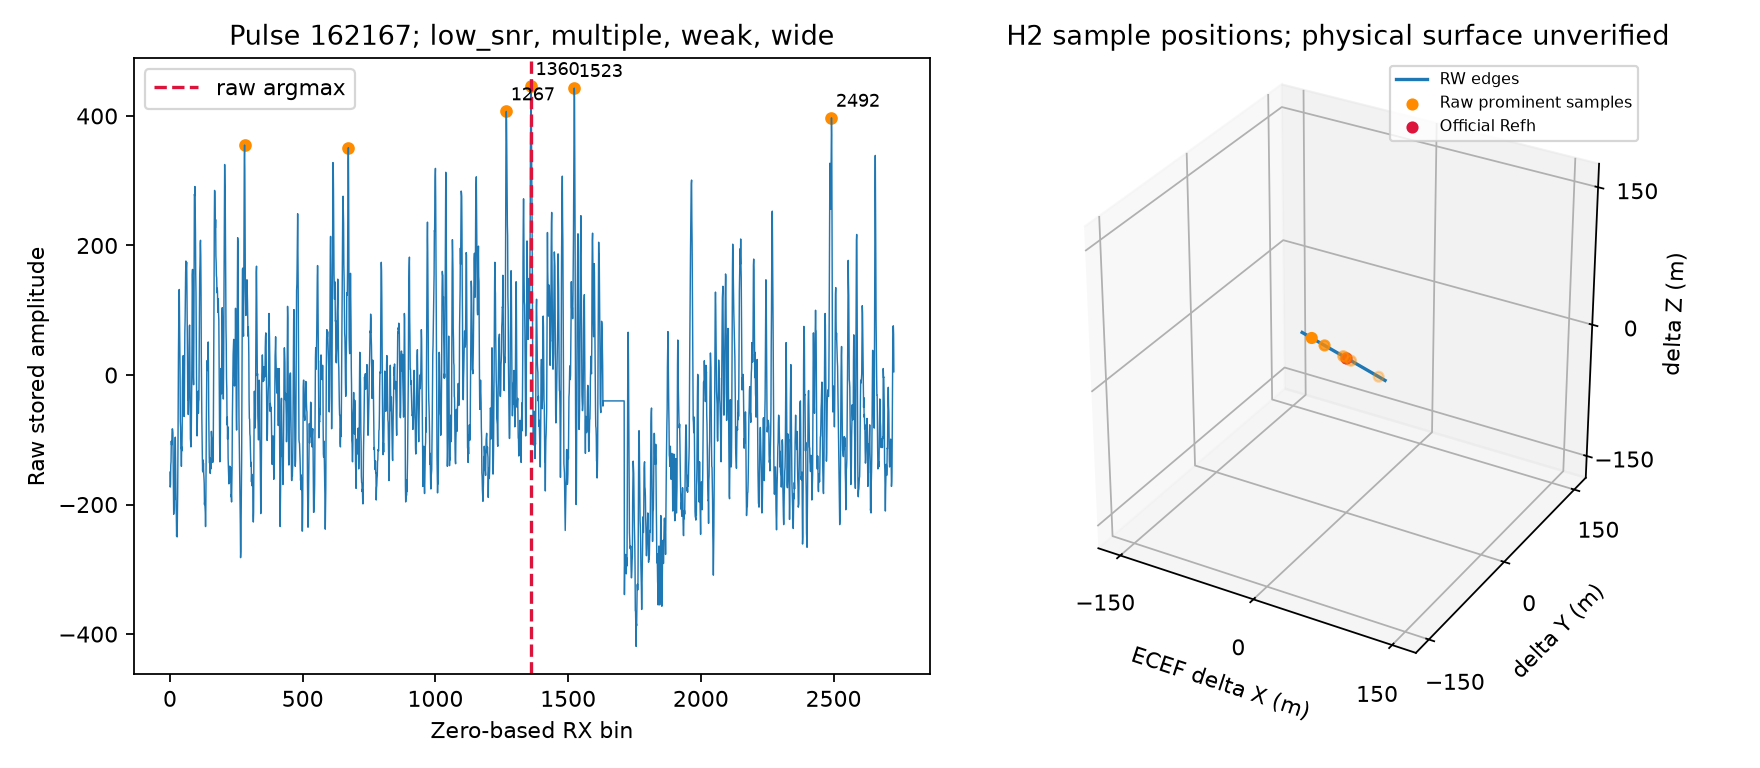

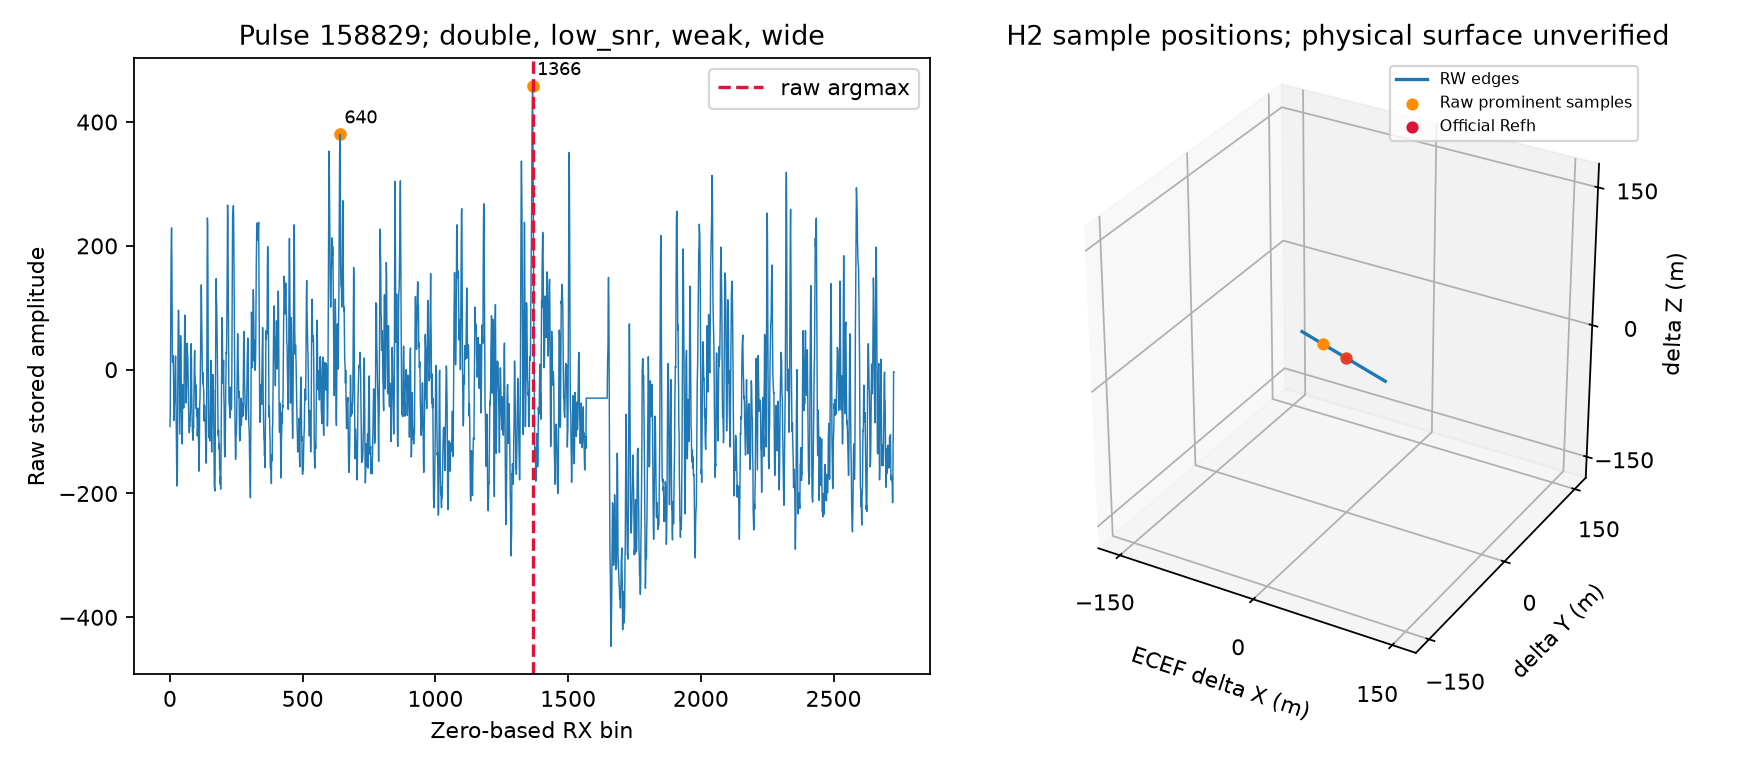

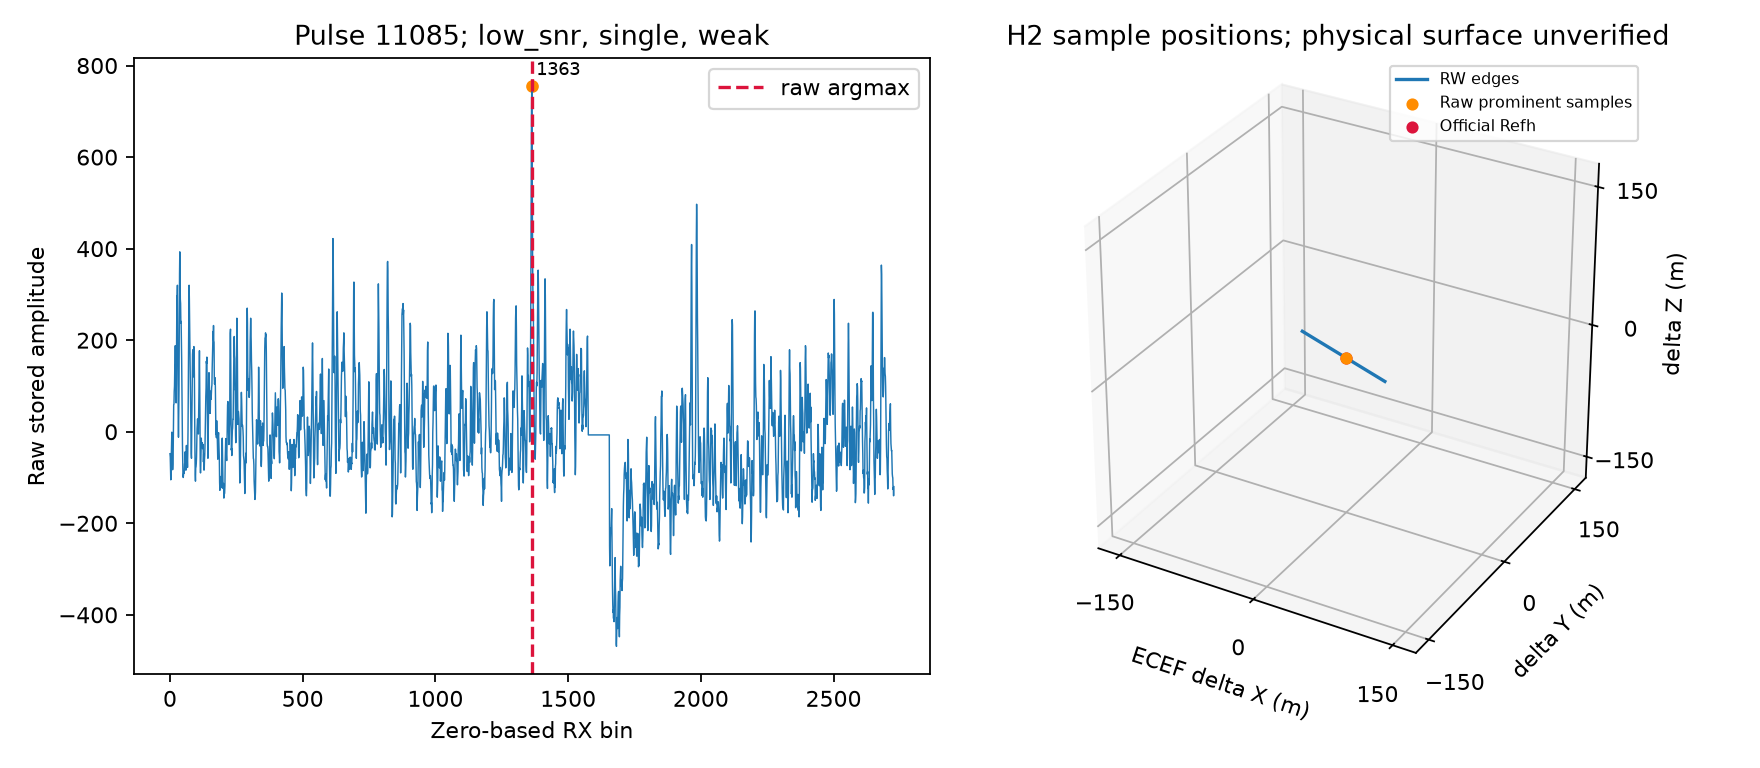

,pulse_index,sweep_num,track_num,labels,raw_peaks,raw_argmax,snr,n_raw_peaks,selection
0,11085,43,106,"low_snr,single,weak",1363,1363,2.267084,1,original seeded examples plus top5 stored SNR;...
1,53917,210,236,"high_snr,single",1657,1657,13.211737,1,original seeded examples plus top5 stored SNR;...
2,58388,228,160,"double,low_snr,weak","1652,1963",1652,2.279641,2,original seeded examples plus top5 stored SNR;...
3,116264,454,65,"high_snr,near_tie,single",1631,1631,11.591598,1,original seeded examples plus top5 stored SNR;...
4,158829,620,107,"double,low_snr,weak,wide","640,1366",1366,1.482520,2,original seeded examples plus top5 stored SNR;...
5,162167,633,187,"low_snr,multiple,weak,wide","281,672,1267,1360,1523,2492",1360,1.439543,6,original seeded examples plus top5 stored SNR;...
6,1724599,6736,189,"boundary,low_snr,single,weak",352,2725,1.415823,1,original seeded examples plus top5 stored SNR;...


,metric,unit,n_total,n_valid,n_rejected,valid_fraction,median,NMAD,P90,P95,P99,max,min,mean
0,H2_along_minus_neutat_linear_residual,numerically compared stored correction to mete...,3604480,3604480,0,1.0,5.504277e-08,3.326683e-07,4.748908e-07,5.398007e-07,0.000001,0.000002,-1.748355e-06,1.130374e-07
1,abs_H2_along_minus_neutat_linear_residual,NaN,3604480,3604480,0,1.0,2.100099e-07,2.672407e-07,5.620811e-07,8.879955e-07,0.000001,0.000002,8.143280e-14,2.847841e-07


,metric,subset,n_total,n_valid,n_rejected,valid_fraction,median,NMAD,P90,P95,P99,max,min,mean
0,H2_along_m,all,3604480,3604480,0,1.0,-0.000529,0.000010,-0.000484,-0.000460,-0.000157,1.982458e-07,-5.551834e-04,-0.000513
1,H2_along_m,high_quality,178079,178079,0,1.0,-0.000524,0.000009,-0.000512,-0.000499,-0.000474,-4.224318e-04,-5.443018e-04,-0.000523
2,H2_perp_m,all,3604480,3604480,0,1.0,0.000004,0.000006,0.000011,0.000011,0.000011,1.109722e-05,4.655097e-10,0.000005
3,H2_perp_m,high_quality,178079,178079,0,1.0,0.000010,0.000001,0.000011,0.000011,0.000011,1.090523e-05,4.186844e-09,0.000007
4,t_times_one_minus_t,all,3604480,3604480,0,1.0,0.238582,0.004025,0.243288,0.244705,0.248359,2.500000e-01,1.832509e-04,0.232303
5,t_times_one_minus_t,high_quality,178079,178079,0,1.0,0.236709,0.003918,0.240022,0.240240,0.242484,2.467508e-01,1.992595e-01,0.236414
6,neutat_ref_minus_linear,all,3604480,3604480,0,1.0,-0.000529,0.000010,-0.000483,-0.000460,-0.000157,-3.086856e-07,-5.551051e-04,-0.000513
7,neutat_ref_minus_linear,high_quality,178079,178079,0,1.0,-0.000525,0.000009,-0.000512,-0.000499,-0.000474,-4.239631e-04,-5.443685e-04,-0.000523
8,H5_Nminus1_vs_H2_first_m,all,3604480,3604480,0,1.0,0.090252,0.002860,0.097392,0.100787,0.125877,1.500698e-01,3.876876e-07,0.089894
9,H5_Nminus1_vs_H2_first_m,high_quality,178079,178079,0,1.0,0.091727,0.002474,0.093572,0.095568,0.100368,1.083468e-01,8.298179e-02,0.091722


In [6]:
for p in GRANULES:
    print(p.name, json.loads((p / 'sample_selection.json').read_text()))
    display(pd.read_csv(p / 'historical_near_tie_case.csv'))
    display(pd.read_csv(p / 'anomalous_pulses.csv').head(10))
    reps=pd.read_csv(p / 'representative_pulses.csv')
    display(reps[reps.is_detected_raw_peak].head(20))
    assert reps.finite.all()
    print('Largest continuity-step residual:', reps.continuity_step_error_m.max())
    for category in ['multiple','double','single','wide','near_tie','boundary','low_snr']:
        examples=sorted((p / 'figures').glob('reviewed_pulse_*_'+category+'.png'))
        if examples: display(Image(filename=str(examples[0])))
    display(pd.read_csv(p / 'reviewed_raw_examples.csv'))
    display(pd.read_csv(p / 'correction_nonlinearity_diagnostic.csv'))
    display(pd.read_csv(p / 'beam_spacing_sensitivity_summary.csv'))

## Scientific decision and acceptance limits
The final report explains all thirteen requested scientific questions. The source hashes and full counts certify a fresh traversal, not externally validated spatial accuracy.

In [7]:
display(Markdown((ROOT / 'research/geolocation/bin_georeferencing_audit/findings.md').read_text(encoding='utf-8')))

# CASALS L1B 任意 RX bin georeferencing：严格验证报告

日期：2026-10-09。结论：**Level 1 — Internally consistent**。推荐研究用 H2：

`P(b) = P_RWSTART + ((b + 0.5) / N) * (P_RWSTOP - P_RWSTART)`。

两份完整原始 H5 重新遍历；没有使用历史 CSV/Notebook 结果替代本轮数据。
该判断不认证任意次峰的官方级或绝对三维精度，也不合并到 production。
Level 2 数值目标的部分几何项满足状态：`True`；字段语义、修正应用及高质量子集的证据门槛仍须逐项看下文。
H2 是当前两个产品的经验上最可靠样本中心映射；不能把 RWSTART/RWSTOP 说成首末样本中心。
H1也可能通过给定的宽松closure／half-bin阈值；阈值不是模型唯一性证明。
选择H2依据连续的bin-center时间关系和亚毫米残差解释，而非为H1或H2调整验收条件。

## 数据与复现证据

|     date |   pulses |   RX_bins |   valid |   high_quality |   outside_segment |   H2_gt_10cm |
|---------:|---------:|----------:|--------:|---------------:|------------------:|-------------:|
| 20241112 |  3604480 |      2728 | 3604480 |             16 |                 0 |            0 |
| 20241118 |  3604480 |      2728 | 3604480 |         178079 |                 0 |            0 |

- `casals_l1b_20241112T165718_001_02.h5`: `637ba73ca9966b86d9243987916c0e60b8fec76c8690d49b7048468ed308cb70`; before/after SHA256 identical.
- `casals_l1b_20241118T171757_001_02.h5`: `dac3d5ed0116083f98944e8d6b0e86f6d812f0f5e4f196cc010add5e382c149a`; before/after SHA256 identical.

RX 实际为 int16、record axis=0、zero-based rx_bins；storage chunks=(14080,11)，逐批14080 pulse读取。
每份 pulse_diagnostics.parquet 保留全部 pulse，包括无效状态；无大规模 waveform 输出。
每个标量的 quantile/NMAD 精确取自全量诊断，并非随机 sample。图中 CDF/scatter 为确定性稀疏绘图样本，统计表为全量。
筛选原因重叠计数，不能将相加当作唯一 invalid 总数。有效几何与原始波形状态分别保存。
两份历史数据都已被早期研究接触，不是盲测；本次固定 H1/H2/H3 与少量历史支持 beam convention。
H4 的5e-10增量只从11月12日首14080条识别，之后冻结。没有 shift/scale 调参。
连续512-sweep blocks中 block%4==3 是验证区，其余为探索区；split_summary.csv逐项报告。
block_uncertainty.csv提供2000次固定seed block-bootstrap的“block median的median”区间，不能视为独立空间真值误差区间。

## 全量数值对照

单位：距离m，角度degree，bin delta为bin；offset单位未正式确认。P95对signed量是signed percentile；absolute bin统计另见bin_agreement.csv。

| metric                            | stat   |          20241112 |          20241118 |
|:----------------------------------|:-------|------------------:|------------------:|
| refh_line_distance_m              | median |    4.41273723e-06 |    4.38646231e-06 |
| refh_line_distance_m              | P95    |    1.10612866e-05 |    1.06818305e-05 |
| refh_line_distance_m              | max    |    1.14534634e-05 |    1.10972438e-05 |
| refh_segment_distance_m           | median |    4.41273723e-06 |    4.38646231e-06 |
| refh_segment_distance_m           | P95    |    1.10612866e-05 |    1.06818305e-05 |
| refh_segment_distance_m           | max    |    1.14534634e-05 |    1.10972438e-05 |
| H1_3d_m                           | median |    0.0163167764   |    0.0154884148   |
| H1_3d_m                           | P95    |    0.0687403545   |    0.0283593388   |
| H1_3d_m                           | max    |    0.0749279418   |    0.0749278182   |
| H2_3d_m                           | median |    0.000526645195 |    0.000529168867 |
| H2_3d_m                           | P95    |    0.00055075425  |    0.000543255296 |
| H2_3d_m                           | max    |    0.000555187167 |    0.000555210761 |
| H3_3d_m                           | median |   91.5785795      |   87.3818573      |
| H3_3d_m                           | P95    |  374.855521       |  156.927244       |
| H3_3d_m                           | max    |  408.728985       |  408.729082       |
| bin_delta_H1                      | median |   -0.093759945    |   -0.102215888    |
| bin_delta_H1                      | P95    |    0.419539779    |   -0.0500412125   |
| bin_delta_H1                      | max    |    0.499820454    |    0.499819421    |
| bin_delta_H2                      | median |    0.00351429739  |    0.00353104538  |
| bin_delta_H2                      | P95    |    0.00367513032  |    0.00362509582  |
| bin_delta_H2                      | max    |    0.00370407001  |    0.0037048113   |
| edge_spacing_m_per_bin            | median |    0.149854754    |    0.149854747    |
| edge_spacing_m_per_bin            | P95    |    0.149854778    |    0.149854811    |
| edge_spacing_m_per_bin            | max    |    0.14985481     |    0.149854903    |
| segment_spacing_m_per_bin         | median |    0.149909707    |    0.149909699    |
| segment_spacing_m_per_bin         | P95    |    0.14990973     |    0.149909763    |
| segment_spacing_m_per_bin         | max    |    0.149909763    |    0.149909855    |
| stored_bin_size                   | median |    0.149623549    |    0.149722498    |
| stored_bin_size                   | P95    |    0.149718638    |    0.149738916    |
| stored_bin_size                   | max    |    0.149725631    |    0.149743129    |
| stored_minus_height_step          | median |    0              |    0              |
| stored_minus_height_step          | P95    |    0              |    0              |
| stored_minus_height_step          | max    |    0              |    0              |
| t_time_minus_geom                 | median |   -1.28823218e-06 |   -1.29437147e-06 |
| t_time_minus_geom                 | P95    |   -2.15521744e-07 |   -1.1261083e-06  |
| t_time_minus_geom                 | max    |    1.17631049e-09 |    4.85856104e-10 |
| time_bin_delta_H2                 | median |    1.98951966e-12 |    9.09494702e-13 |
| time_bin_delta_H2                 | P95    |    1.04591891e-11 |    7.27595761e-12 |
| time_bin_delta_H2                 | max    |    1.86446414e-11 |    1.18234311e-11 |
| bounce_step_per_bin               | median |    5e-10          |    5e-10          |
| bounce_step_per_bin               | P95    |    5e-10          |    5e-10          |
| bounce_step_per_bin               | max    |    5e-10          |    5e-10          |
| RW_vs_beam_refh_deg               | median |    0.000133355519 |    0.000108665412 |
| RW_vs_beam_refh_deg               | P95    |    0.000212080328 |    0.000681132783 |
| RW_vs_beam_refh_deg               | max    |    0.000338077941 |    0.00113309767  |
| RW_vs_beam_instrument_deg         | median |    0.00416810767  |    0.00197220458  |
| RW_vs_beam_instrument_deg         | P95    |    0.00582069248  |    0.0148988698   |
| RW_vs_beam_instrument_deg         | max    |    0.0067734716   |    0.015531542    |
| RW_vs_IR_deg                      | median |    4.79393728e-06 |    3.41066434e-05 |
| RW_vs_IR_deg                      | P95    |    7.20054851e-06 |    0.000227826592 |
| RW_vs_IR_deg                      | max    |    9.42069909e-06 |    0.000246698325 |
| conditional_c_half_minus_length_m | median | -204.345314       | -204.345293       |
| conditional_c_half_minus_length_m | P95    | -204.345243       | -204.345216       |
| conditional_c_half_minus_length_m | max    | -204.345182       | -204.345013       |

## 1–5：端点、映射和整数／fractional bin

1. RWSTART/RWSTOP 实际有height、lon、lat三元组，因此可作为3D位置进行研究计算；H5没有这些字段的语义attrs。
   `refh` 的WGS84椭球高由[NASA/CryoCloud官方教程](https://book.cryointhecloud.com/l1b-waveforms-tutorial/)支持。
   RW height和instrument altitude采用同一椭球约定是经验支持的工作假设，官方逐字段frame/epoch仍未知。
2. 与bin 0和N−1的关系：数值证据支持RW是window edges，sample centers位于 `(b+0.5)/N`。
   H1的首末bin-center假设产生随bin变化的半bin形态偏差，不能解释成已确认的官方约定。
   用zero-based数组索引b；若输入一基编号j，则b=j−1，不能直接代入j。
3. 当前推荐H2；逆向H3被闭合结果否定。H4经验时间候选与H2近乎等价，不是另一份完全独立定位模型。
4. 任意整数bin使用H2 affine ECEF式，再从EPSG:4978转换EPSG:4979得到lon/lat/ellipsoidal h。
5. Fractional bin直接使用相同连续式，不round、不clip。法律域0≤b≤N−1；数学window edges是−0.5和N−0.5，公开函数拒绝域外edge索引。
   真实非参考样本检验端点、argmax附近+.4bin、远离Refh的quartile bins和raw局部峰；代表样本CSV保存finite/连续性step残差。

## 6–8：bin_size、时间、beam

6. stored bin_size没有units/description。当前最显著新证据是它与 `(rwstart-rwstop)/N` 的高度步长相等，而与ECEF沿束步长不同。
   `stored_minus_sin_elevation_step`提供另一几何关系检验。不能直接当沿束m/bin使用，亦不能将数值相等升级为正式字段定义。
   本轮定位优先使用window edge length/N；length/(N−1)是H1的spacing，必须分开。
7. 时间比例 `(tau_refh-tau_start)/(tau_stop-tau_start)` 与几何参数比较，反推center bin使用 `N*t_time−0.5`。
   window offset span/N 的5e-10增量由全量比较检验；绝对offset是约e-5量级，不足以决定clock、双程/单程、sign和时刻含义。
   global `sec_to_meters=c/2`、`ns_to_meters` 是记录的处理常数，但没有直接把offset字段绑定seconds的说明。
   conditional `span*c`/`span*c/2`诊断明确标为假设单位秒；segment的光速差异不能武断归因某一已应用修正。
   在“offset单位秒”的条件下，实测span*c接近完整RW长度，而span*c/2约为一半：

| metric                            | stat   |     20241112 |     20241118 |
|:----------------------------------|:-------|-------------:|-------------:|
| segment_length_m                  | median |  408.80377   |  408.803749  |
| bounce_span                       | median |    1.364e-06 |    1.364e-06 |
| conditional_span_times_c_m        | median |  408.916913  |  408.916913  |
| conditional_span_times_c_half_m   | median |  204.458456  |  204.458456  |
| conditional_c_half_minus_length_m | median | -204.345314  | -204.345293  |

   因此这些bounce offset的数值行为不支持直接作为raw双程传播时延再乘c/2。
   5e-10若为单程bounce increment，对应raw双程1ns采样与global ns_to_meters常数相容；
   这仍是处理后字段关系的经验解释，clock/time-zero及processing convention须CASALS确认。
8. radian、north-clockwise、horizon elevation、negated ENU在Refh local basis与RW方向相符。
   同一规则的instrument basis、错误degree解释和反向sign也有全量对照；未做无边界angle搜索。
   RW/IR/beam方向、instrument beam line端点perpendicular distance均已计算。
   非零instrument差异可能包含local basis、时刻、frame或lever arm，不能全部归罪beam角。

## 候选方法及证据独立性

|候选|所需字段／数学定义|判定与限制|
|---|---|---|
|H1|RW三元组、N；P0+b/(N−1)*v|闭合厘米级；center约定不匹配当前时间/bin关系|
|H2|RW三元组、N；P0+(b+.5)/N*v|研究推荐；无Refh锚定；仍须官方字段定义和修正模型确认|
|H3|RW三元组、N；P0+(1−b/(N−1))*v|FAIL：反向索引不支持|
|H4 official|sample timing定义和offset单位|UNAVAILABLE：缺明确sample timing／单位契约|
|H4 empirical|RW、offsets；tau_start+(b+.5)*5e−10|经验等价H2；时间关系支持内部一致性，不是独立绝对精度|
|H5 N−1 spacing|Refh三元组、raw br、beam角和local basis；Pr+(b−br)*length/(N−1)*d|锚定闭合恒为0；作为模型比较，不能定位精度验收|
|H5 edge spacing|同上，length/N|另一spacing版本，与H2的真实非refh一致性报告|
|H6 stored spacing|同上，stored bin_size|物理range model UNAVAILABLE；数值敏感性计算仅为诊断，units/height-vs-range未正式确认|

两种H5 spacing的全量first/last sample discrepancy见beam_spacing_sensitivity_summary.csv。
各模型的真实secondary／fractional比较见non_refh_model_comparison.csv，保存XYZ和相对H2差异。
H5在br处closure=0是定义；H5/segment agreement也不是外部精度。
所有candidate ECEF单位m，geodetic是EPSG:4979下椭球高；endpoint输入unit/frame仍受上述契约限制。

## 9–10：厘米偏差、近并列和异常

H1相对H2的parameter差为 `(b−(N−1)/2)/(N*(N−1))`，所以存在bin位置依赖的最多约半bin的沿束差。
这一差异无需人为平移即可解释主要厘米级H1残差；remaining H2 residual不得自动归因已知校正。
补充读取原始neutat_delay_total，计算 `delay_refh−[delay_start+t_center*(delay_stop−delay_start)]`。
它与signed H2沿束残差的数值关系如下，未将任何修正重新应用于坐标：

|     date | x          | y                       |    pearson_r |
|---------:|:-----------|:------------------------|-------------:|
| 20241112 | H2_along_m | t_times_one_minus_t     | -0.999988317 |
| 20241112 | H2_along_m | neutat_ref_minus_linear |  0.999998692 |
| 20241118 | H2_along_m | t_times_one_minus_t     | -0.993332876 |
| 20241118 | H2_along_m | neutat_ref_minus_linear |  0.999978493 |

|     date |         median |            P95 |            max |
|---------:|---------------:|---------------:|---------------:|
| 20241112 | 9.61088841e-08 | 5.62631958e-07 | 9.98901491e-07 |
| 20241118 | 2.10009912e-07 | 8.87995455e-07 | 1.84756508e-06 |

这一近似等量的数值证据支持“不同range处大气修正非线性影响endpoint interpolation residual”的解释，
比单独相关性更强，但修正字段单位／applied状态和官方处理过程仍未知，不能据此私自修正任意bin或宣称处理器parity。
H2 affine给出endpoint模型坐标，未捕捉逐range非线性；当前对Refh实测的亚毫米差不可自动外推为所有bin的误差上界。
原始max规则与同值／近值计数保留，未固定任何bin改善closure。

历史案例在两份新读原始数据中的实际值：

|     date |   pulse_index |   sweep_num |   track_num |   argmax_bin |   amp_1693 |   amp_1694 |   max_amplitude |   tie_count |
|---------:|--------------:|------------:|------------:|-------------:|-----------:|-----------:|----------------:|------------:|
| 20241112 |       1280218 |        5000 |         214 |          346 |        -42 |         -5 |             451 |           1 |
| 20241118 |       1280218 |        5000 |         214 |         1694 |       1850 |       1860 |            1860 |           1 |

int16存储值的numpy argmax在float64转换后完全精确；当前记录不能据此证明浮点环境导致1693/1694逆转。
若旧实验使用smoothing、fitting、不同产品版本、不同pulse索引或其他waveform表示，它的近并列结论不能直接转移到当前raw H5。
归档v2中beam winner在Refh basis、radian、north-clockwise、negated elevation方向的假设可复核；
归档的b/(N−1)不能作为“唯一正确约定”延续，当前增加H2后具有更强内部支持。

最大H2残差具体记录（不从总体删去）：

|     date |   pulse_index |   sweep_num |   track_num |        H2_3d_m |   bin_delta_H2 |   refh_line_distance_m |
|---------:|--------------:|------------:|------------:|---------------:|---------------:|-----------------------:|
| 20241112 |        563521 |        2201 |          10 | 0.000555187167 |  0.00370407001 |         1.12695827e-05 |
| 20241112 |        614944 |        2402 |           1 | 0.000555177403 |  0.00370402563 |         1.11432444e-05 |
| 20241112 |        610466 |        2384 |          21 | 0.000555173018 |  0.0037039906  |         1.11786181e-05 |
| 20241118 |        158829 |         620 |         107 | 0.000555210761 |  0.0037048113  |         5.51666213e-06 |
| 20241118 |        177005 |         691 |         107 | 0.000555206107 |  0.00370478761 |         5.41543937e-06 |
| 20241118 |        182167 |         711 |         188 | 0.000555174817 |  0.00370456772 |         5.54935961e-06 |

每份anomalous_pulses.csv同时包括line距离、beam角、同track的segment长度／方向跳变前十条。
异常的threshold计数、geometry/RX rejection、out-of-bounds和instrument order见run_metadata.json；
同track连续性表不把不同track的交错record当作同一扫描线跳变。
高质量阈值SNR≥10、unique maximum、top-two差>1 ADU，未依赖闭合误差调参；为空时不补造样本。

|     date | subset       | model   |   population_total |   n_used |   screening_rejected |   within_half_bin |   within_one_bin |    signed_bias |
|---------:|:-------------|:--------|-------------------:|---------:|---------------------:|------------------:|-----------------:|---------------:|
| 20241112 | all          | H1      |            3604480 |  3604480 |                    0 |                 1 |                1 | -0.093759945   |
| 20241112 | all          | H2      |            3604480 |  3604480 |                    0 |                 1 |                1 |  0.00351429739 |
| 20241112 | high_quality | H1      |            3604480 |       16 |              3604464 |                 1 |                1 | -0.102956471   |
| 20241112 | high_quality | H2      |            3604480 |       16 |              3604464 |                 1 |                1 |  0.00353309347 |
| 20241118 | all          | H1      |            3604480 |  3604480 |                    0 |                 1 |                1 | -0.102215888   |
| 20241118 | all          | H2      |            3604480 |  3604480 |                    0 |                 1 |                1 |  0.00353104538 |
| 20241118 | high_quality | H1      |            3604480 |   178079 |              3426401 |                 1 |                1 | -0.111864754   |
| 20241118 | high_quality | H2      |            3604480 |   178079 |              3426401 |                 1 |                1 |  0.00349987478 |

另提供不要求SNR阈值的明确argmax子集unambiguous_argmax_agreement.csv，保留unfiltered总体。

## 11：真实非Refh示例

|     date |   pulse_index |   sweep_num |   track_num | category   |   bin |   raw_argmax |   longitude |   latitude |   ellipsoidal_height |   H5_minus_H2_m |
|---------:|--------------:|------------:|------------:|:-----------|------:|-------------:|------------:|-----------:|---------------------:|----------------:|
| 20241112 |        102901 |         401 |         175 | multiple   |  2588 |         1560 | -75.280252  | 38.4041177 |          -166.668649 |  0.000735515267 |
| 20241118 |         11085 |          43 |         106 | low_snr    |    37 |         1363 | -76.6772818 | 36.1923731 |           207.154766 |  0.000639512357 |
| 20241118 |         11085 |          43 |         106 | low_snr    |    72 |         1363 | -76.6772843 | 36.1923732 |           201.914519 |  0.000635466253 |
| 20241118 |         11085 |          43 |         106 | low_snr    |    90 |         1363 | -76.6772856 | 36.1923733 |           199.219535 |  0.000633416658 |
| 20241118 |         11085 |          43 |         106 | low_snr    |   111 |         1363 | -76.677287  | 36.1923734 |           196.075387 |  0.000631053135 |
| 20241118 |         11085 |          43 |         106 | low_snr    |   139 |         1363 | -76.677289  | 36.1923734 |           191.883189 |  0.000627948284 |

代表pulse具有真实raw waveform局部峰，图示waveform和对应相对Refh ECEF3D。
这些未确认峰来自冠层、地面或建筑；raw局部峰和sample bin不能直接称独立物理scatterer。
宽峰／低SNR／边界／近并列等类别只按raw形态和stored SNR标注；缺失类别明确记录，不fabricate。
- casals_l1b_20241112T165718_001_02: missing fields []; invalid/overlapping-reason counts in `run_metadata.json`; reviewed raw morphology missing categories []. 初轮sample_selection.json中的类别因互斥优先标签可能掩盖形态，补充reviewed_raw_examples.csv采用并行标签，单独记录更强对比选择规则。
- casals_l1b_20241118T171757_001_02: missing fields []; invalid/overlapping-reason counts in `run_metadata.json`; reviewed raw morphology missing categories []. 初轮sample_selection.json中的类别因互斥优先标签可能掩盖形态，补充reviewed_raw_examples.csv采用并行标签，单独记录更强对比选择规则。

## 12–13：能主张的精度与官方问题

能主张的是本轮两个granule内部的Refh closure／时间／beam数值一致性及研究函数的连续性。
不能把这些差异当绝对空间精度、secondary return uncertainty、官方处理器parity或ground accuracy。
**保守判定Level 1**：几何数值证据强，但H2没有处理实测存在的逐range非线性修正；
尚不能建立非Refh bin处的修正、有效时间模型或误差界，offset物理语义和RW高度frame仍未充分约束。
这一判断不单纯因为缺官方确认（官方确认另属Level 3）；问题是当前affine任意bin模型的重要物理假设仍未闭合。
不得只因漂亮closure或达到诊断阈值提升到Level 2/3/4。强经验支持与官方确认在证据矩阵分开。
现有3DEP两份LAZ已读取header（external_reference_inventory.json）：horizontal NAD83(2011)/UTM18N；
未在header建立vertical datum、coordinate epoch、准确采集时间和共位置表面。文件creation date是派生文件生成日期，不能替代采集日期。
因此没有直接比较CASALS椭球高与未知3DEP高程；external absolute accuracy为NOT VERIFIED。
H5列出L1A/ARD/GPS/geolocation输入名称，但当前目录没有对应完整中间产品；TDMS并非同一L1B定位处理器的可直接替代真值。

必须向CASALS确认：RW代表sample edges还是centers；offset单位／clock／bounce定义；sample time zero／间隔；
bin_size是否明确为height increment；RW/instrument/refh reference frame、epoch和vertical datum；
beam angle方向和local origin；range_bias/neutat/geoid/tides/dac是否applied；
不同range位置的校正是否非线性，以及H2是否与官方processor逐bin等价。

## bin_to_xyz函数完整契约与production建议

输入：start_xyz/stop_xyz为broadcastable (...,3) ECEF meter、有限且非零segment；
bins为broadcastable实数数组，0≤b≤N−1；n_bins是integer≥2；convention H1/H2/H3（默认H2）。
输出：同broadcast形状的ECEF XYZ meter。无效／域外／unknown convention抛ValueError，不extrapolate／clip。
fractional直接affine；输入应是该pulse的正确window和N，不内置pulse顺序假设。
本函数不执行peak detection、不重施任何correction、不认证sample是物理return。
**建议暂不纳入production**：先取得正式字段／processor确认，并处理异常与非参考range校正模型。
本轮只新增研究和测试，production geolocation、detection/classification/Refh及原始H5不变。

## 验收与执行命令

A（数据真实性）全量两文件、bounded reads和before/after hashes已记录；B（字段契约）未知明确保留；
C/D（几何／mapping）line vs segment、raw argmax和三个index候选均实算；
E（timing／beam）数值检查完成但official semantics NOT VERIFIED；
F（nonrefh）integer/fractional及真实raw示例完成，external accuracy NOT VERIFIED；
G（软件）pytest／compileall结果见validation.json。研究执行完成不代表科学的所有证据门槛PASS。

```powershell
conda activate map
python research/geolocation/bin_georeferencing_audit/run_audit.py --mode smoke --output-root outputs/research/bin_georeferencing_audit/smoke_new
python research/geolocation/bin_georeferencing_audit/run_audit.py --mode full --output-root outputs/research/bin_georeferencing_audit/full_new
python -m research.geolocation.bin_georeferencing_audit.complete_report --output-root outputs/research/bin_georeferencing_audit/full_new
python -m pytest -q
python -m compileall -q research/geolocation/bin_georeferencing_audit tests
```

analysis.ipynb的可见AUDIT配置须指向新运行目录；执行notebook只读取本轮已验证输出。
源文档：仓库docs/casals_l1b_pulse_waveform_geolocation_notes.md、两份archived geolocation notebooks和历史beam audit script仅作待复核资料；
官方教程检索日期2026-10-09，直接URL打开出现404，但网页检索索引可读取内容。不能宣称获取了官方完整processor说明。
